# Step 27: 데이터 증강 v2 (power_estimate 원본 기반 + OBS 날씨)

In [3]:
# ================================================
# Step 27: 데이터 증강 v2
# 원본: power_estimate_full_2021.csv (1~9/14)
# 증강: 9/15~12/31
#   - OBS 기상청 실측 날씨 완벽 반영
#   - 원본 1~9월 생산구분 시간대별 비율 그대로 유지
#   - 생산량 Z-score 보정 (전체 mean=467, std=858 유지)
#   - 생산구분별 피크: Q1/Q3 수식 (15번 노트북 방식)
#   - 공휴일: 추석·개천절·한글날·크리스마스 반영
# ================================================
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import os
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# ── 1) power_estimate 원본 로드 (1~9/14만 사용) ──────────────────
for p in [
    r'C:\Users\Admin\hipython\ml\data\power_estimate_full_2021.csv',
    r'C:\Users\Admin\hipython\data\power_estimate_full_2021.csv',
    './data/power_estimate_full_2021.csv',
]:
    if os.path.exists(p):
        df_pe = pd.read_csv(p)
        print(f"power_estimate 로드: {p}")
        break

df_orig = df_pe[df_pe['날짜'] <= 20210914].copy()
print(f"원본(1~9/14): {len(df_orig):,}행")
print(f"컬럼: {df_orig.columns.tolist()}")

# ── 2) OBS 기상청 로드 ────────────────────────────────────────────
for p in [
    r'C:\Users\Admin\hipython\ml\data\OBS_ASOS_TIM_20260319115729.csv',
    './data/OBS_ASOS_TIM_20260319115729.csv',
]:
    if os.path.exists(p):
        df_obs = pd.read_csv(p, encoding='cp949')
        print(f"OBS 로드: {p}")
        break

df_obs['일시']     = pd.to_datetime(df_obs['일시'])
df_obs['날짜_key'] = df_obs['일시'].dt.strftime('%Y%m%d').astype(int)
df_obs['시간_key'] = df_obs['일시'].dt.hour
df_obs = df_obs.rename(columns={
    '기온(°C)':'기온','풍속(m/s)':'풍속',
    '습도(%)':'습도','강수량(mm)':'강수량',
})
df_obs['강수량'] = df_obs['강수량'].fillna(0)
df_obs['풍속']   = df_obs['풍속'].fillna(df_obs['풍속'].median())
df_obs['기온']   = df_obs['기온'].interpolate().bfill()
df_obs['습도']   = df_obs['습도'].interpolate().bfill()
print(f"OBS: {len(df_obs):,}행 | {df_obs['날짜_key'].min()}~{df_obs['날짜_key'].max()}")

# ── 3) 원본 생산구분 시간대별 실측 비율 ──────────────────────────
RATIO_DAY_WD   = {0:0.164, 1:0.673, 2:0.141, 3:0.006, 4:0.016}  # 주간 평일
RATIO_NIGHT_WD = {0:0.316, 1:0.102, 2:0.504, 3:0.053, 4:0.025}  # 야간 평일
RATIO_HOLIDAY  = {0:0.871, 1:0.002, 2:0.088, 3:0.037, 4:0.002}  # 주말/공휴일

def pick_grade(ratio_dict):
    grades = list(ratio_dict.keys())
    probs  = list(ratio_dict.values())
    return int(np.random.choice(grades, p=probs))

# ── 4) 생산구분별 통계 (원본 1~9/14 실측) ─────────────────────────
STATS = {
    0: {'peak_q1':22,  'peak_q3':61,  'prod_mean':0,    'prod_std':0,    'work_mean':0.00},
    1: {'peak_q1':155, 'peak_q3':174, 'prod_mean':1389, 'prod_std':1070, 'work_mean':2.13},
    2: {'peak_q1':103, 'peak_q3':118, 'prod_mean':392,  'prod_std':698,  'work_mean':0.84},
    3: {'peak_q1':64,  'peak_q3':85,  'prod_mean':380,  'prod_std':538,  'work_mean':1.43},
    4: {'peak_q1':22,  'peak_q3':24,  'prod_mean':585,  'prod_std':847,  'work_mean':6.34},
}

def gen_peak(g, prod):
    s = STATS[g]
    if g == 0:
        base = np.random.uniform(s['peak_q1'], s['peak_q3'])
        return round(float(np.clip(base + np.random.normal(0,5), 5, 200)), 1)
    if g == 4:
        return round(float(np.clip(np.random.uniform(20,26), 15, 30)), 1)
    base  = s['peak_q1'] * 0.7
    cap   = s['peak_q3'] * 0.9
    mxp   = s['prod_mean'] + 2 * s['prod_std']
    ratio = min(prod / mxp, 1.0) if mxp > 0 else 0
    noise = np.random.normal(0, (cap - base) * 0.08)
    return round(float(np.clip(base + ratio*(cap-base) + noise, 5, 210)), 1)

def gen_prod(g):
    s = STATS[g]
    if g == 0: return 0
    return max(0, int(np.random.normal(s['prod_mean'], s['prod_std'])))

def gen_work(g):
    s = STATS[g]
    if g == 0: return 0.0
    return max(0.0, round(np.random.normal(s['work_mean'], s['work_mean']*0.3+0.1), 2))

# ── 5) 공휴일 정의 ────────────────────────────────────────────────
ALL_HOLIDAYS = {
    20210101,20210211,20210212,20210301,
    20210505,20210519,20210816,
    20210731,20210801,20210802,20210803,
    20210804,20210805,20210806,20210807,20210808,
    20210920,20210921,20210922,
    20211003,20211004,20211009,20211225,
}

# ── 6) 9/15~12/31 증강 행 생성 ───────────────────────────────────
rows = []
cur  = datetime(2021, 9, 15)
while cur <= datetime(2021, 12, 31, 23):
    날짜   = int(cur.strftime('%Y%m%d'))
    시간   = cur.hour
    월     = cur.month
    일     = cur.day
    요일   = cur.isoweekday()
    is_wk  = int(요일 >= 6)
    is_hol = int(날짜 in ALL_HOLIDAYS)
    is_off = int(is_wk==1 or is_hol==1)
    is_day = int(9 <= 시간 <= 18)

    grade = pick_grade(RATIO_HOLIDAY if is_off else
                       RATIO_DAY_WD  if is_day  else
                       RATIO_NIGHT_WD)

    prod    = gen_prod(grade)
    work    = gen_work(grade)
    p15     = gen_peak(grade, prod)
    p30     = round(float(np.clip(p15+np.random.normal(0,3),0,215)),1)
    p45     = round(float(np.clip(p15+np.random.normal(0,3),0,215)),1)
    p60     = round(float(np.clip(p15+np.random.normal(0,3),0,215)),1)
    pavg    = round((p15+p30+p45+p60)/4, 1)
    tariff  = 191.6 if 월 in [6,7,8] else (109.8 if 월 in [11,12,1,2] else 167.2)
    ikb     = 1.0 if 9<=시간<=18 else 1.5

    rows.append({
        '날짜_시간':f"{cur.strftime('%Y-%m-%d')} {시간}:00",
        '날짜':날짜,'시간':시간,
        '15분':p15,'30분':p30,'45분':p45,'60분':p60,'최대전력평균':pavg,
        '생산량':prod,'기온':np.nan,'풍속':np.nan,'습도':np.nan,'강수량':np.nan,
        '전기요금(계절)':tariff,'요일':요일,'일자':일,'월':월,
        '공장인원':work,'인건비할증':ikb,'생산구분':grade,
        '추정사용전력량':np.nan,'주말여부':is_wk,'휴일여부':is_hol,
    })
    cur += timedelta(hours=1)

df_aug = pd.DataFrame(rows)

# ── 7) OBS 날씨 병합 ─────────────────────────────────────────────
df_aug['날짜_key'] = df_aug['날짜'].astype(int)
df_aug['시간_key'] = df_aug['시간'].astype(int)
df_aug = df_aug.merge(
    df_obs[['날짜_key','시간_key','기온','풍속','습도','강수량']],
    on=['날짜_key','시간_key'], how='left', suffixes=('_drop','')
)
for c in ['기온','풍속','습도','강수량']:
    if f'{c}_drop' in df_aug.columns:
        df_aug[c] = df_aug[c].fillna(df_aug[f'{c}_drop'])
        df_aug = df_aug.drop(columns=[f'{c}_drop'])
    df_aug[c] = df_aug[c].interpolate().bfill().ffill()
df_aug = df_aug.drop(columns=['날짜_key','시간_key'])

# ── 8) Z-score 보정: 생산량 mean=467, std=858 유지 ────────────────
TARGET_MEAN, TARGET_STD = 467.3, 857.6
prod_arr = df_aug['생산량'].values.astype(float)
nonzero  = prod_arr > 0
if nonzero.sum() > 0:
    cm, cs = prod_arr[nonzero].mean(), prod_arr[nonzero].std()
    if cs > 0:
        prod_arr[nonzero] = (prod_arr[nonzero]-cm)/cs * TARGET_STD + TARGET_MEAN
    prod_arr = np.clip(prod_arr, 0, None)
    df_aug['생산량'] = prod_arr.round(0).astype(int)
df_aug.loc[df_aug['주말여부']==1, '생산량'] = 0
df_aug.loc[df_aug['휴일여부']==1, '생산량'] = 0

# ── 9) 추정사용전력량 역산 (15번 노트북 방식) ─────────────────────
def calc_usage(row):
    g, peak, prod = row['생산구분'], row['최대전력평균'], row['생산량']
    if g == 0:
        return round(float(np.clip(peak * 0.7, 15, 150)), 1)
    if g == 4:
        return round(float(np.clip(peak * 0.7, 15, 150)), 1)
    s  = STATS[g]
    base = s['peak_q1'] * 0.7
    cap  = s['peak_q3'] * 0.9
    mxp  = s['prod_mean'] + 2 * s['prod_std']
    r    = min(prod/mxp, 1.0) if mxp>0 else 0
    val  = base + r*(cap-base)
    return round(float(np.clip(val, 15, 150)), 1)

df_aug['추정사용전력량'] = df_aug.apply(calc_usage, axis=1)

# ── 10) 원본 + 증강 합치기 ────────────────────────────────────────
common = [c for c in df_orig.columns if c in df_aug.columns]
df_work = pd.concat(
    [df_orig[common], df_aug[common]],
    ignore_index=True
).sort_values(['날짜','시간']).reset_index(drop=True)

# ── 11) 최종 확인 ─────────────────────────────────────────────────
print(f"\n=== 증강 결과 ===")
print(f"원본: {len(df_orig):,}행 / 증강: {len(df_aug):,}행 / 전체: {len(df_work):,}행")
print(f"날짜범위: {df_work['날짜'].min()} ~ {df_work['날짜'].max()}")
print(f"\n생산량: 전체 mean={df_work['생산량'].mean():.1f} std={df_work['생산량'].std():.1f}")
print(f"        증강 mean={df_aug['생산량'].mean():.1f} std={df_aug['생산량'].std():.1f}")
print(f"피크  : 전체 mean={df_work['15분'].mean():.1f}")
print(f"        증강 mean={df_aug['15분'].mean():.1f}")
print(f"비가동: 전체 {(df_work['생산량']==0).mean()*100:.1f}% / 증강 {(df_aug['생산량']==0).mean()*100:.1f}%")
print(f"\n생산구분 분포(증강):")
print(df_aug['생산구분'].value_counts().sort_index().to_dict())

os.makedirs('./data', exist_ok=True)
df_work.to_csv('./data/okm_full_2021_pe.csv', index=False, encoding='utf-8-sig')
print(f"\n저장 완료: ./data/okm_full_2021_pe.csv")
print("Step 27 완료")


power_estimate 로드: ./data/power_estimate_full_2021.csv
원본(1~9/14): 6,168행
컬럼: ['날짜_시간', '날짜', '시간', '15분', '30분', '45분', '60분', '최대전력평균', '생산량', '기온', '풍속', '습도', '강수량', '전기요금(계절)', '요일', '일자', '월', '공장인원', '인건비할증', '생산구분', '추정사용전력량', '주말여부', '휴일여부']
OBS 로드: ./data/OBS_ASOS_TIM_20260319115729.csv
OBS: 8,736행 | 20210101~20211231

=== 증강 결과 ===
원본: 6,168행 / 증강: 2,592행 / 전체: 8,760행
날짜범위: 20210101 ~ 20211231

생산량: 전체 mean=402.9 std=790.6
        증강 mean=249.7 std=573.9
피크  : 전체 mean=85.1
        증강 mean=72.4
비가동: 전체 51.9% / 증강 73.0%

생산구분 분포(증강):
{0: 1175, 1: 600, 2: 694, 3: 90, 4: 33}

저장 완료: ./data/okm_full_2021_pe.csv
Step 27 완료


# Step 28: df_work 로드 확인

In [4]:
# ================================================
# Step 28: df_work 로드 확인
# ================================================
import pandas as pd
import numpy as np
import os

df_work = pd.read_csv('./data/okm_full_2021_pe.csv', encoding='utf-8-sig')
print(f"df_work 로드 완료")
print(f"행 수  : {len(df_work):,}")
print(f"컬럼   : {df_work.columns.tolist()}")
print(f"날짜   : {df_work['날짜'].min()} ~ {df_work['날짜'].max()}")
print(f"결측치 : {df_work.isnull().sum().sum()}개")
print(f"\n월별 행수:")
월col = '월' if '월' in df_work.columns else None
if 월col:
    print(df_work[월col].value_counts().sort_index().to_dict())
print("\nStep 28 완료")


df_work 로드 완료
행 수  : 8,760
컬럼   : ['날짜_시간', '날짜', '시간', '15분', '30분', '45분', '60분', '최대전력평균', '생산량', '기온', '풍속', '습도', '강수량', '전기요금(계절)', '요일', '일자', '월', '공장인원', '인건비할증', '생산구분', '추정사용전력량', '주말여부', '휴일여부']
날짜   : 20210101 ~ 20211231
결측치 : 0개

월별 행수:
{1: 744, 2: 672, 3: 744, 4: 720, 5: 744, 6: 720, 7: 744, 8: 744, 9: 720, 10: 744, 11: 720, 12: 744}

Step 28 완료


# Step 29: GMM생산구분 컬럼 생성 (pe 원본 생산구분 활용)

In [5]:
# ================================================
# Step 29: GMM생산구분 컬럼 생성
# power_estimate 원본은 생산구분 이미 포함
# → 컬럼명만 GMM생산구분으로 통일, 구분4→3 통합
# ================================================
import pandas as pd
import numpy as np

if '생산구분' in df_work.columns:
    df_work['GMM생산구분'] = df_work['생산구분'].copy()
    df_work.loc[df_work['GMM생산구분']==4, 'GMM생산구분'] = 3
    print("생산구분 → GMM생산구분 복사 완료 (구분4→3 통합)")
else:
    conditions = [
        df_work['생산량'] == 0,
        df_work['생산량'] >= 1000,
        df_work['생산량'] >= 200,
        df_work['생산량'] > 0,
    ]
    df_work['GMM생산구분'] = np.select(conditions, [0,1,2,3], default=0)
    print("생산구분 없음 → 생산량 기준 대체 분류")

print(f"\n=== GMM생산구분 분포 ===")
print(df_work['GMM생산구분'].value_counts().sort_index().to_string())
print(f"\n=== 생산구분별 평균 피크(15분) ===")
print(df_work.groupby('GMM생산구분')['15분'].mean().round(1).to_string())
print(f"\ndf_work 컬럼 수: {df_work.shape[1]}")
print("Step 29 완료")


생산구분 → GMM생산구분 복사 완료 (구분4→3 통합)

=== GMM생산구분 분포 ===
GMM생산구분
0    3832
1    2095
2    2401
3     432

=== 생산구분별 평균 피크(15분) ===
GMM생산구분
0     44.0
1    149.1
2    100.1
3     55.9

df_work 컬럼 수: 24
Step 29 완료


# Step 30: 달력 파생변수 생성 (공장 여름휴가 포함)

In [9]:
# ================================================
# Step 30: 달력 파생변수 생성
# pe 기반 파일: 요일/주말여부/휴일여부 컬럼 사용
# ================================================
national_holidays = [
    20210101, 20210211, 20210212, 20210301,
    20210505, 20210519, 20210816,
    20210920, 20210921, 20210922,
    20211003, 20211004, 20211009, 20211225,
]
summer_vacation = [
    20210731, 20210801, 20210802, 20210803,
    20210804, 20210805, 20210806, 20210807, 20210808,
]
all_holidays = set(national_holidays + summer_vacation)

# ── pe 파일 컬럼명 기준으로 처리 ──────────────────
# 요일 컬럼 → day 컬럼 생성 (Step 34 Feature Set 호환)
if 'day' not in df_work.columns:
    if '요일' in df_work.columns:
        df_work['day'] = df_work['요일']
    else:
        df_work['day'] = pd.to_datetime(
            df_work['날짜'].astype(str), format='%Y%m%d'
        ).dt.isoweekday()

# is_holiday
if 'is_holiday' not in df_work.columns:
    if '휴일여부' in df_work.columns:
        df_work['is_holiday'] = df_work['휴일여부'].astype(int)
    else:
        df_work['is_holiday'] = df_work['날짜'].isin(all_holidays).astype(int)

# is_weekend
if 'is_weekend' not in df_work.columns:
    if '주말여부' in df_work.columns:
        df_work['is_weekend'] = df_work['주말여부'].astype(int)
    else:
        df_work['is_weekend'] = (df_work['day'] >= 6).astype(int)

# weekday (0=월~6=일, sklearn 호환)
df_work['weekday'] = df_work['day'] - 1

# d, m (일, 월)
if 'd' not in df_work.columns:
    if '일자' in df_work.columns:
        df_work['d'] = df_work['일자']
    else:
        df_work['d'] = pd.to_datetime(
            df_work['날짜'].astype(str), format='%Y%m%d'
        ).dt.day

if 'm' not in df_work.columns:
    if '월' in df_work.columns:
        df_work['m'] = df_work['월']
    else:
        df_work['m'] = pd.to_datetime(
            df_work['날짜'].astype(str), format='%Y%m%d'
        ).dt.month

# 주간여부 (9~18시)
df_work['주간여부'] = df_work['시간'].between(9, 18).astype(int)

print(f"is_holiday  : {df_work['is_holiday'].sum():,}건")
print(f"is_weekend  : {df_work['is_weekend'].sum():,}건")
print(f"주간여부(1) : {df_work['주간여부'].sum():,}건")
print(f"day 샘플    : {sorted(df_work['day'].unique())}")
print(f"m   샘플    : {sorted(df_work['m'].unique())}")
print("\nStep 30 완료")

is_holiday  : 552건
is_weekend  : 2,496건
주간여부(1) : 3,650건
day 샘플    : [1, 2, 3, 4, 5, 6, 7]
m   샘플    : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

Step 30 완료


# Step 31: 가동여부 파생

In [10]:
# ================================================
# Step 31: 가동여부 파생
# ================================================
df_work['가동여부'] = (df_work['생산량'] > 0).astype(int)

on  = df_work['가동여부'].sum()
off = len(df_work) - on
print(f"가동  (1): {on:,}건 ({on/len(df_work)*100:.1f}%)")
print(f"비가동(0): {off:,}건 ({off/len(df_work)*100:.1f}%)")
print(f"\n가동여부별 평균 전력:")
print(df_work.groupby('가동여부')['15분'].agg(['mean','min','max']).round(1).to_string())
print("\nStep 31 완료")


가동  (1): 4,211건 (48.1%)
비가동(0): 4,549건 (51.9%)

가동여부별 평균 전력:
       mean  min    max
가동여부                   
0      49.7  0.0  196.0
1     123.3  0.0  207.0

Step 31 완료


# Step 32: furnace_on 열처리로 역추론

In [11]:
# ================================================
# Step 32: furnace_on 열처리로 역추론
# ================================================
df_work['furnace_on'] = 0
df_work.loc[df_work['가동여부']==1, 'furnace_on'] = 1
df_work.loc[
    (df_work['가동여부']==0) & (df_work['15분']>=60),
    'furnace_on'] = 1

# 불확실 구간(30~60kW) ffill
ambiguous = (df_work['가동여부']==0) & (df_work['15분']>=30) & (df_work['15분']<60)
df_work.loc[ambiguous, 'furnace_on'] = -1
df_work['furnace_on'] = df_work['furnace_on'].replace(-1, np.nan)
df_work['furnace_on'] = df_work['furnace_on'].fillna(method='ffill').fillna(0).astype(int)

print(f"furnace_on ON : {df_work['furnace_on'].sum():,}건 ({df_work['furnace_on'].mean()*100:.1f}%)")
print(f"furnace_on OFF: {(df_work['furnace_on']==0).sum():,}건")
print("\nStep 32 완료")


furnace_on ON : 6,233건 (71.2%)
furnace_on OFF: 2,527건

Step 32 완료


# Step 33: TOU / SMP / CO2 / 인건비 병합

In [13]:
# ================================================
# Step 33: TOU / SMP / CO2 / 인건비 병합
# ================================================
def get_tou(month, hour, is_holiday, is_weekend):
    if is_holiday or is_weekend: return 0, 95.7
    if month in [6,7,8]:
        if hour in [10,11,12,13,14,15,16,17]: return 2, 155.0
        if hour in [22,23,0,1,2,3,4,5]:       return 0, 95.7
        return 1, 121.5
    elif month in [11,12,1,2]:
        if hour in [9,10,17,18,19]:            return 2, 155.0
        if hour in [22,23,0,1,2,3,4,5]:        return 0, 95.7
        return 1, 121.5
    else:
        if hour in [10,11,12,13,14,15,16,17]:  return 1, 121.5
        if hour in [22,23,0,1,2,3,4,5]:        return 0, 95.7
        return 1, 121.5

SMP_2021 = {
    1:70.47, 2:75.25, 3:83.78, 4:75.97, 5:78.93,
    6:82.72, 7:87.04, 8:93.41, 9:98.21,
    10:107.53, 11:126.83, 12:142.46
}
EMISSION = 0.4153  # tCO2eq/MWh (온실가스종합정보센터 2021)

tou_result = df_work.apply(
    lambda r: get_tou(r['m'], r['시간'], r['is_holiday'], r['is_weekend']),
    axis=1
)
df_work['tou_bucket'] = [r[0] for r in tou_result]
df_work['tou_price']  = [r[1] for r in tou_result]
df_work['smp_land']   = df_work['m'].map(SMP_2021)
# pe 파일은 '최대전력평균', okm 파일은 '평균' 컬럼 사용
peak_col = '최대전력평균' if '최대전력평균' in df_work.columns else '평균'
df_work['co2_kg'] = (df_work[peak_col] / 1000 * EMISSION * 1000).round(3)

print("=== TOU 구간 분포 ===")
for b, label, price in [(0,'경부하',95.7),(1,'중간부하',121.5),(2,'최대부하',155.0)]:
    cnt = (df_work['tou_bucket']==b).sum()
    print(f"  구간{b} {label:6s} ({price}원/kWh): {cnt:,}건")
print(f"\nSMP 범위: {df_work['smp_land'].min():.2f} ~ {df_work['smp_land'].max():.2f} 원/kWh")
print(f"CO2 평균: {df_work['co2_kg'].mean():.2f} kg/h")
print("\nStep 33 완료")


=== TOU 구간 분포 ===
  구간0 경부하    (95.7원/kWh): 4,840건
  구간1 중간부하   (121.5원/kWh): 3,025건
  구간2 최대부하   (155.0원/kWh): 895건

SMP 범위: 70.47 ~ 142.46 원/kWh
CO2 평균: 36.22 kg/h

Step 33 완료


# Step 33-1: log1p 변환

In [14]:
# ================================================
# Step 33-1: log1p 변환
# 대상: 생산량, 강수량, 공장인원, 풍속
# ================================================
log_cols = ['생산량', '강수량', '공장인원', '풍속']
df_log = df_work.copy()

print("=== log1p 변환 전후 비교 ===")
for col in log_cols:
    bm, bs = df_log[col].mean(), df_log[col].std()
    df_log[col] = np.log1p(df_log[col])
    am, as_ = df_log[col].mean(), df_log[col].std()
    print(f"  [{col}] 전: mean={bm:.2f} std={bs:.2f} → 후: mean={am:.2f} std={as_:.2f}")

print(f"\n원본 df_work: {df_work.shape} (보존)")
print(f"변환 df_log : {df_log.shape}")
print("Step 33-1 완료")


=== log1p 변환 전후 비교 ===
  [생산량] 전: mean=402.94 std=790.64 → 후: mean=2.85 std=3.15
  [강수량] 전: mean=1.60 std=8.13 → 후: mean=0.27 std=0.76
  [공장인원] 전: mean=0.88 std=1.78 → 후: mean=0.44 std=0.55
  [풍속] 전: mean=2.05 std=1.15 → 후: mean=1.04 std=0.40

원본 df_work: (8760, 37) (보존)
변환 df_log : (8760, 37)
Step 33-1 완료


# Step 33-2: 최종 피처 데이터 저장

In [15]:
# ================================================
# Step 33-2: 최종 피처 데이터 저장
# ================================================
os.makedirs('./data', exist_ok=True)
save_path = './data/okm_enriched_final.csv'
df_log.to_csv(save_path, index=False, encoding='utf-8-sig')
size_kb = os.path.getsize(save_path) / 1024

missing = df_log.isnull().sum()
missing = missing[missing>0]
print("결측치:" , "없음 ✅" if len(missing)==0 else missing.to_string())
print(f"\n=== 최종 데이터 요약 ===")
print(f"행 수    : {len(df_log):,}")
print(f"컬럼 수  : {df_log.shape[1]}")
print(f"날짜 범위: {df_log['날짜'].min()} ~ {df_log['날짜'].max()}")
print(f"파일 크기: {size_kb:.1f} KB")
print(f"저장 경로: {save_path}")
print(f"\n전체 컬럼:")
for i, c in enumerate(df_log.columns, 1):
    print(f"  {i:2d}. {c}")
print("Step 33-2 완료")


결측치: 없음 ✅

=== 최종 데이터 요약 ===
행 수    : 8,760
컬럼 수  : 37
날짜 범위: 20210101 ~ 20211231
파일 크기: 1582.7 KB
저장 경로: ./data/okm_enriched_final.csv

전체 컬럼:
   1. 날짜_시간
   2. 날짜
   3. 시간
   4. 15분
   5. 30분
   6. 45분
   7. 60분
   8. 최대전력평균
   9. 생산량
  10. 기온
  11. 풍속
  12. 습도
  13. 강수량
  14. 전기요금(계절)
  15. 요일
  16. 일자
  17. 월
  18. 공장인원
  19. 인건비할증
  20. 생산구분
  21. 추정사용전력량
  22. 주말여부
  23. 휴일여부
  24. GMM생산구분
  25. is_holiday
  26. day
  27. is_weekend
  28. weekday
  29. d
  30. m
  31. 주간여부
  32. 가동여부
  33. furnace_on
  34. tou_bucket
  35. tou_price
  36. smp_land
  37. co2_kg
Step 33-2 완료


# Step 34: Feature Set A / B / C / D 정의 

In [16]:
# ================================================
# Step 34: Feature Set A / B / C 정의
# Set_A: 날짜·시간·달력만
# Set_B: Set_A + 날씨
# Set_C: Set_B + 생산·GMM·furnace_on·전기요금 전체 (파생 전부 포함)
# co2_kg 제외 (타겟 직접 파생 — 데이터 누수)
# ================================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

TARGET = '15분'

def safe_cols(cols):
    missing = [c for c in cols if c not in df_log.columns]
    if missing:
        print(f"  없는 컬럼 제외: {missing}")
    return [c for c in cols if c in df_log.columns]

FEATURE_SETS = {
    # Set_A: 날짜·시간·달력 파생만
    'Set_A': safe_cols([
        '시간', 'day', 'd', 'm',
        'weekday', 'is_weekend', 'is_holiday', '주간여부',
    ]),
    # Set_B: Set_A + 날씨
    'Set_B': safe_cols([
        '시간', 'day', 'd', 'm',
        'weekday', 'is_weekend', 'is_holiday', '주간여부',
        '기온', '습도', '풍속', '강수량',
    ]),
    # Set_C: Set_B + 생산정보 + GMM + furnace_on + 전기요금 파생 전체
    'Set_C': safe_cols([
        '시간', 'day', 'd', 'm',
        'weekday', 'is_weekend', 'is_holiday', '주간여부',
        '기온', '습도', '풍속', '강수량',
        '생산량', '가동여부', '공장인원',
        'GMM생산구분', 'furnace_on',
        '전기요금(계절)', 'tou_bucket', 'tou_price',
        'smp_land', '인건비',
        # co2_kg 제외 (타겟 직접 파생 — 데이터 누수)
    ]),
}

print("=== Feature Set 구성 ===")
for name, cols in FEATURE_SETS.items():
    print(f"  {name} ({len(cols):2d}개): {cols}")

# Train/Test 분할 (랜덤 8:2)
X_all = df_log[FEATURE_SETS['Set_C']]
y     = df_log[TARGET]
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

# Set별 슬라이싱
splits = {}
for name, cols in FEATURE_SETS.items():
    splits[name] = {
        'X_train': X_train[cols],
        'X_test' : X_test[cols],
    }

# 스케일링 (DNN·Linear용)
scalers = {}
for name, cols in FEATURE_SETS.items():
    sc = StandardScaler()
    splits[name]['X_train_sc'] = sc.fit_transform(splits[name]['X_train'])
    splits[name]['X_test_sc']  = sc.transform(splits[name]['X_test'])
    scalers[name] = sc

print(f"\nTrain: {len(X_train):,}행 / Test: {len(X_test):,}행")
print(f"y 평균: Train={y_train.mean():.1f}kW / Test={y_test.mean():.1f}kW")

def grade_dist(s):
    return {
        '양호(<70)'    :(s<70).sum(),
        '주의(70~110)' :((s>=70)&(s<110)).sum(),
        '위험(110~150)':((s>=110)&(s<150)).sum(),
        '초과(>=150)'  :(s>=150).sum(),
    }
gd_tr = grade_dist(y_train)
gd_te = grade_dist(y_test)
print(f"\n피크 등급 분포:")
for k in gd_tr:
    print(f"  {k}: Train={gd_tr[k]:,}건 / Test={gd_te[k]:,}건")

print(f"\nSet_A ({len(FEATURE_SETS['Set_A'])}개): 날짜·시간·달력")
print(f"Set_B ({len(FEATURE_SETS['Set_B'])}개): Set_A + 날씨")
print(f"Set_C ({len(FEATURE_SETS['Set_C'])}개): Set_B + 생산·GMM·furnace_on·전기요금")
print("Step 34 완료")

  없는 컬럼 제외: ['인건비']
=== Feature Set 구성 ===
  Set_A ( 8개): ['시간', 'day', 'd', 'm', 'weekday', 'is_weekend', 'is_holiday', '주간여부']
  Set_B (12개): ['시간', 'day', 'd', 'm', 'weekday', 'is_weekend', 'is_holiday', '주간여부', '기온', '습도', '풍속', '강수량']
  Set_C (21개): ['시간', 'day', 'd', 'm', 'weekday', 'is_weekend', 'is_holiday', '주간여부', '기온', '습도', '풍속', '강수량', '생산량', '가동여부', '공장인원', 'GMM생산구분', 'furnace_on', '전기요금(계절)', 'tou_bucket', 'tou_price', 'smp_land']

Train: 7,008행 / Test: 1,752행
y 평균: Train=85.0kW / Test=85.4kW

피크 등급 분포:
  양호(<70): Train=2,825건 / Test=694건
  주의(70~110): Train=1,737건 / Test=451건
  위험(110~150): Train=1,485건 / Test=354건
  초과(>=150): Train=961건 / Test=253건

Set_A (8개): 날짜·시간·달력
Set_B (12개): Set_A + 날씨
Set_C (21개): Set_B + 생산·GMM·furnace_on·전기요금
Step 34 완료


# Feature Set 구성표 시각화

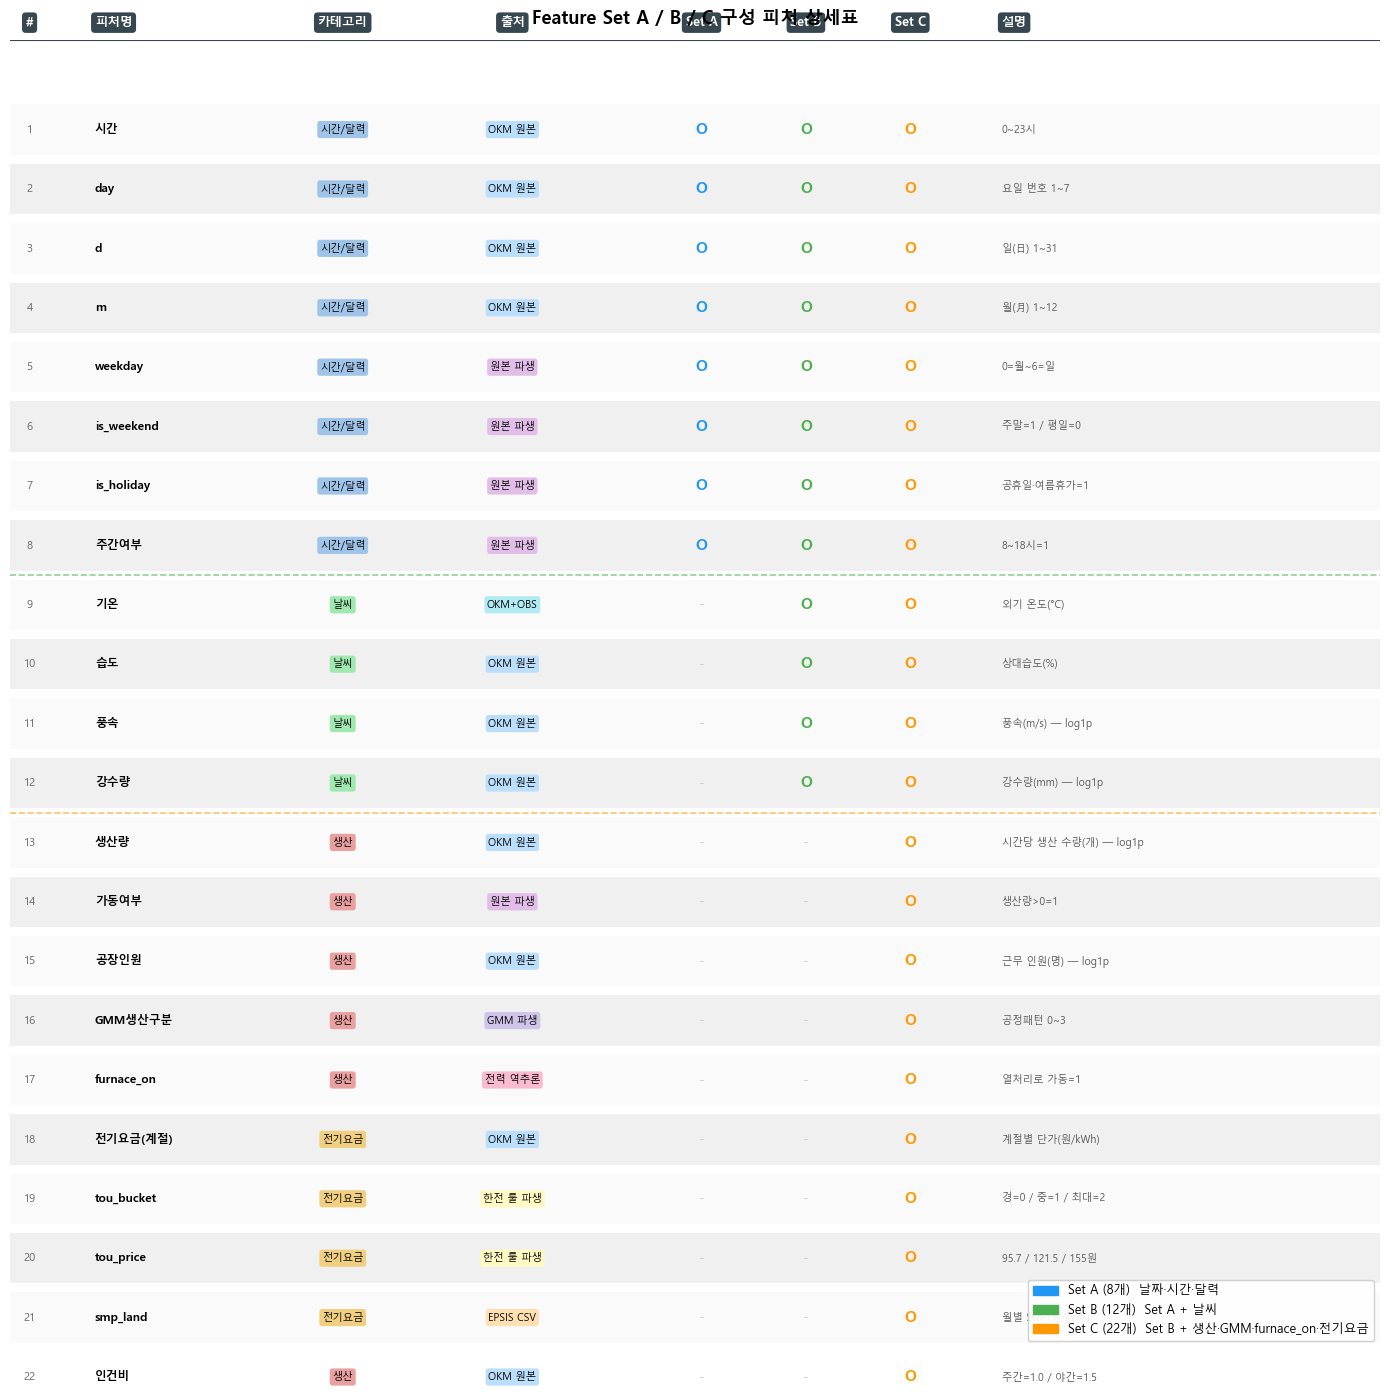

Feature Set 구성표 완료


In [17]:
# ================================================
# Step 34-1: Feature Set A / B / C 구성표 시각화
# ================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib
import numpy as np

matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

feature_info = [
    # (피처명, 카테고리, 출처, SetA, SetB, SetC, 설명)
    ('시간',          '시간/달력', 'OKM 원본',    True,  True,  True,  '0~23시'),
    ('day',          '시간/달력', 'OKM 원본',    True,  True,  True,  '요일 번호 1~7'),
    ('d',            '시간/달력', 'OKM 원본',    True,  True,  True,  '일(日) 1~31'),
    ('m',            '시간/달력', 'OKM 원본',    True,  True,  True,  '월(月) 1~12'),
    ('weekday',      '시간/달력', '원본 파생',   True,  True,  True,  '0=월~6=일'),
    ('is_weekend',   '시간/달력', '원본 파생',   True,  True,  True,  '주말=1 / 평일=0'),
    ('is_holiday',   '시간/달력', '원본 파생',   True,  True,  True,  '공휴일·여름휴가=1'),
    ('주간여부',       '시간/달력', '원본 파생',   True,  True,  True,  '8~18시=1'),
    ('기온',          '날씨',     'OKM+OBS',    False, True,  True,  '외기 온도(°C)'),
    ('습도',          '날씨',     'OKM 원본',    False, True,  True,  '상대습도(%)'),
    ('풍속',          '날씨',     'OKM 원본',    False, True,  True,  '풍속(m/s) — log1p'),
    ('강수량',         '날씨',     'OKM 원본',    False, True,  True,  '강수량(mm) — log1p'),
    ('생산량',         '생산',     'OKM 원본',    False, False, True,  '시간당 생산 수량(개) — log1p'),
    ('가동여부',        '생산',     '원본 파생',   False, False, True,  '생산량>0=1'),
    ('공장인원',        '생산',     'OKM 원본',    False, False, True,  '근무 인원(명) — log1p'),
    ('GMM생산구분',    '생산',     'GMM 파생',    False, False, True,  '공정패턴 0~3'),
    ('furnace_on',   '생산',     '전력 역추론',  False, False, True,  '열처리로 가동=1'),
    ('전기요금(계절)', '전기요금',  'OKM 원본',    False, False, True,  '계절별 단가(원/kWh)'),
    ('tou_bucket',   '전기요금',  '한전 룰 파생', False, False, True,  '경=0 / 중=1 / 최대=2'),
    ('tou_price',    '전기요금',  '한전 룰 파생', False, False, True,  '95.7 / 121.5 / 155원'),
    ('smp_land',     '전기요금',  'EPSIS CSV',   False, False, True,  '월별 SMP(원/kWh)'),
    ('인건비',         '생산',     'OKM 원본',    False, False, True,  '주간=1.0 / 야간=1.5'),
]

n = len(feature_info)

set_colors = {
    'A': '#2196F3',
    'B': '#4CAF50',
    'C': '#FF9800',
}
cat_colors = {
    '생산'    : '#E8A0A0',
    '시간/달력': '#A0C4E8',
    '날씨'    : '#A0E8B0',
    '전기요금' : '#F0D080',
}
src_color_map = {
    'OKM 원본'   : '#BBDEFB',
    '원본 파생'   : '#E1BEE7',
    'OKM+OBS'   : '#B2EBF2',
    'GMM 파생'   : '#D1C4E9',
    '한전 룰 파생': '#FFF9C4',
    'EPSIS CSV' : '#FFE0B2',
    '전력 역추론' : '#F8BBD0',
}

fig, ax = plt.subplots(figsize=(14, 14))
ax.set_xlim(0, 10.5)
ax.set_ylim(-0.5, n - 0.5)
ax.axis('off')

col_x = {
    'num'   : 0.15,
    'feat'  : 0.65,
    'cat'   : 2.55,
    'source': 3.85,
    'setA'  : 5.3,
    'setB'  : 6.1,
    'setC'  : 6.9,
    'desc'  : 7.6,
}

# ── 헤더 ─────────────────────────────────────────
header_y = n - 0.2
for col, label, ha in [
    ('num',    '#',       'center'),
    ('feat',   '피처명',   'left'),
    ('cat',    '카테고리', 'center'),
    ('source', '출처',    'center'),
    ('setA',   'Set A',  'center'),
    ('setB',   'Set B',  'center'),
    ('setC',   'Set C',  'center'),
    ('desc',   '설명',    'left'),
]:
    ax.text(col_x[col], header_y, label,
            ha=ha, va='center',
            fontsize=9, fontweight='bold', color='white',
            bbox=dict(boxstyle='round,pad=0.3', fc='#37474F', ec='none'))

ax.axhline(n - 0.5, color='#37474F', linewidth=1.5)

# ── 행 그리기 ─────────────────────────────────────
for i, row in enumerate(feature_info):
    feat, cat, src, sa, sb, sc, desc = row
    y = n - 2 - i

    bg = '#FAFAFA' if i % 2 == 0 else '#F0F0F0'
    ax.barh(y, 10.5, left=0, height=0.85, color=bg, zorder=0)

    ax.text(col_x['num'],  y, str(i+1),
            ha='center', va='center', fontsize=8, color='#666')
    ax.text(col_x['feat'], y, feat,
            ha='left', va='center', fontsize=8.5, fontweight='bold')
    ax.text(col_x['cat'],  y, cat,
            ha='center', va='center', fontsize=7.5,
            bbox=dict(boxstyle='round,pad=0.25',
                      fc=cat_colors.get(cat, '#EEE'), ec='none'))
    ax.text(col_x['source'], y, src,
            ha='center', va='center', fontsize=7.5,
            bbox=dict(boxstyle='round,pad=0.25',
                      fc=src_color_map.get(src, '#EEE'), ec='none'))

    for flag, col_key, key in [
        (sa, 'setA', 'A'),
        (sb, 'setB', 'B'),
        (sc, 'setC', 'C'),
    ]:
        if flag:
            ax.text(col_x[col_key], y, 'O',
                    ha='center', va='center',
                    fontsize=11, fontweight='bold',
                    color=set_colors[key])
        else:
            ax.text(col_x[col_key], y, '-',
                    ha='center', va='center',
                    fontsize=10, color='#CCCCCC')

    ax.text(col_x['desc'], y, desc,
            ha='left', va='center', fontsize=7.5, color='#555')

# ── Set 구분선 ────────────────────────────────────
ax.axhline(n - 2 - 7.5, color='#4CAF50',
           linewidth=1.2, linestyle='--', alpha=0.6)
ax.axhline(n - 2 - 11.5, color='#FF9800',
           linewidth=1.2, linestyle='--', alpha=0.6)

# ── 범례 ─────────────────────────────────────────
set_a_cnt = sum(r[3] for r in feature_info)
set_b_cnt = sum(r[4] for r in feature_info)
set_c_cnt = sum(r[5] for r in feature_info)

legend_patches = [
    mpatches.Patch(color=set_colors['A'],
                   label=f"Set A ({set_a_cnt}개)  날짜·시간·달력"),
    mpatches.Patch(color=set_colors['B'],
                   label=f"Set B ({set_b_cnt}개)  Set A + 날씨"),
    mpatches.Patch(color=set_colors['C'],
                   label=f"Set C ({set_c_cnt}개)  Set B + 생산·GMM·furnace_on·전기요금"),
]
ax.legend(handles=legend_patches, loc='lower right',
          fontsize=9, framealpha=0.9)

plt.title('Feature Set A / B / C 구성 피처 상세표',
          fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()
print("Feature Set 구성표 완료")

# Step 35: LinearRegression

In [18]:
# ================================================
# Step 35: LinearRegression
# ================================================
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

results = []

def evaluate(model_name, model, X_tr, X_te, y_tr, y_te, set_name):
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    r2   = r2_score(y_te, pred)
    rmse = np.sqrt(mean_squared_error(y_te, pred))
    mae  = mean_absolute_error(y_te, pred)
    results.append({
        '모델': model_name, 'Set': set_name,
        'R²': round(r2,4), 'RMSE': round(rmse,2), 'MAE': round(mae,2),
    })
    print(f"  {model_name:20s} [{set_name:8s}] "
          f"R²={r2:.4f}  RMSE={rmse:.2f}  MAE={mae:.2f}")
    return model

print("=== Step 35: LinearRegression ===")
for fs_name in FEATURE_SETS:
    evaluate('LinearReg', LinearRegression(),
             splits[fs_name]['X_train_sc'],
             splits[fs_name]['X_test_sc'],
             y_train, y_test, fs_name)

print("Step 35 완료")

=== Step 35: LinearRegression ===
  LinearReg            [Set_A   ] R²=0.3235  RMSE=42.24  MAE=33.38
  LinearReg            [Set_B   ] R²=0.3328  RMSE=41.94  MAE=33.34
  LinearReg            [Set_C   ] R²=0.7841  RMSE=23.86  MAE=17.49
Step 35 완료


# Step 36: Ridge

In [19]:
# ================================================
# Step 36: Ridge
# ================================================
from sklearn.linear_model import Ridge

print("=== Step 36: Ridge ===")
for fs_name in FEATURE_SETS:
    evaluate('Ridge', Ridge(alpha=1.0),
             splits[fs_name]['X_train_sc'],
             splits[fs_name]['X_test_sc'],
             y_train, y_test, fs_name)

print("Step 36 완료")

=== Step 36: Ridge ===
  Ridge                [Set_A   ] R²=0.3235  RMSE=42.24  MAE=33.38
  Ridge                [Set_B   ] R²=0.3328  RMSE=41.94  MAE=33.35
  Ridge                [Set_C   ] R²=0.7841  RMSE=23.86  MAE=17.49
Step 36 완료


# Step 37: DecisionTree

In [20]:
# ================================================
# Step 37: DecisionTree
# ================================================
from sklearn.tree import DecisionTreeRegressor

print("=== Step 37: DecisionTree ===")
for fs_name in FEATURE_SETS:
    evaluate('DecisionTree',
             DecisionTreeRegressor(random_state=42),
             splits[fs_name]['X_train'],
             splits[fs_name]['X_test'],
             y_train, y_test, fs_name)

print("Step 37 완료")

=== Step 37: DecisionTree ===
  DecisionTree         [Set_A   ] R²=0.7268  RMSE=26.84  MAE=15.32
  DecisionTree         [Set_B   ] R²=0.7039  RMSE=27.94  MAE=16.26
  DecisionTree         [Set_C   ] R²=0.9387  RMSE=12.72  MAE=8.17
Step 37 완료


# Step 38: RandomForest

In [21]:
# ================================================
# Step 38: RandomForest
# n_jobs=1 필수 (Windows TerminatedWorkerError 방지)
# ================================================
from sklearn.ensemble import RandomForestRegressor

print("=== Step 38: RandomForest ===")
for fs_name in FEATURE_SETS:
    evaluate('RandomForest',
             RandomForestRegressor(
                 n_estimators=100,
                 random_state=42,
                 n_jobs=1),
             splits[fs_name]['X_train'],
             splits[fs_name]['X_test'],
             y_train, y_test, fs_name)

print("\n=== 중간 결과 요약 ===")
df_results = pd.DataFrame(results).sort_values(
    ['Set', 'R²'], ascending=[True, False])
print(df_results.to_string(index=False))

print("Step 38 완료")

=== Step 38: RandomForest ===
  RandomForest         [Set_A   ] R²=0.8421  RMSE=20.40  MAE=12.30
  RandomForest         [Set_B   ] R²=0.8343  RMSE=20.91  MAE=13.32
  RandomForest         [Set_C   ] R²=0.9660  RMSE=9.47  MAE=6.47

=== 중간 결과 요약 ===
          모델   Set     R²  RMSE   MAE
RandomForest Set_A 0.8421 20.40 12.30
DecisionTree Set_A 0.7268 26.84 15.32
   LinearReg Set_A 0.3235 42.24 33.38
       Ridge Set_A 0.3235 42.24 33.38
RandomForest Set_B 0.8343 20.91 13.32
DecisionTree Set_B 0.7039 27.94 16.26
   LinearReg Set_B 0.3328 41.94 33.34
       Ridge Set_B 0.3328 41.94 33.35
RandomForest Set_C 0.9660  9.47  6.47
DecisionTree Set_C 0.9387 12.72  8.17
   LinearReg Set_C 0.7841 23.86 17.49
       Ridge Set_C 0.7841 23.86 17.49
Step 38 완료


# Step 39: XGBoost

In [22]:
# ================================================
# Step 39: XGBoost
# n_jobs=1 필수 (Windows TerminatedWorkerError 방지)
# ================================================
from xgboost import XGBRegressor

print("=== Step 39: XGBoost ===")
for fs_name in FEATURE_SETS:
    evaluate('XGBoost',
             XGBRegressor(
                 n_estimators=300,
                 random_state=42,
                 verbosity=0,
                 n_jobs=1),
             splits[fs_name]['X_train'],
             splits[fs_name]['X_test'],
             y_train, y_test, fs_name)

print("\n=== 현재까지 전체 결과 ===")
df_results = pd.DataFrame(results).sort_values(
    ['Set', 'R²'], ascending=[True, False])
print(df_results.to_string(index=False))

print("Step 39 완료")

=== Step 39: XGBoost ===
  XGBoost              [Set_A   ] R²=0.8049  RMSE=22.68  MAE=14.37
  XGBoost              [Set_B   ] R²=0.8043  RMSE=22.72  MAE=15.52
  XGBoost              [Set_C   ] R²=0.9641  RMSE=9.72  MAE=6.96

=== 현재까지 전체 결과 ===
          모델   Set     R²  RMSE   MAE
RandomForest Set_A 0.8421 20.40 12.30
     XGBoost Set_A 0.8049 22.68 14.37
DecisionTree Set_A 0.7268 26.84 15.32
   LinearReg Set_A 0.3235 42.24 33.38
       Ridge Set_A 0.3235 42.24 33.38
RandomForest Set_B 0.8343 20.91 13.32
     XGBoost Set_B 0.8043 22.72 15.52
DecisionTree Set_B 0.7039 27.94 16.26
   LinearReg Set_B 0.3328 41.94 33.34
       Ridge Set_B 0.3328 41.94 33.35
RandomForest Set_C 0.9660  9.47  6.47
     XGBoost Set_C 0.9641  9.72  6.96
DecisionTree Set_C 0.9387 12.72  8.17
   LinearReg Set_C 0.7841 23.86 17.49
       Ridge Set_C 0.7841 23.86 17.49
Step 39 완료


# Step 40: DNN 3종 (Shallow / Medium / Deep)

In [23]:
# ================================================
# Step 40: DNN 3종 (Set_C 기준만 학습)
# ================================================
from sklearn.neural_network import MLPRegressor

print("=== Step 40: DNN 3종 (Set_C 기준) ===")

dnn_models = {
    'DNN-Shallow' : (64,),
    'DNN-Medium'  : (128, 64),
    'DNN-Deep'    : (128, 64, 32),
}

for model_name, layers in dnn_models.items():
    evaluate(model_name,
             MLPRegressor(
                 hidden_layer_sizes=layers,
                 max_iter=500,
                 random_state=42,
                 early_stopping=True),
             splits['Set_C']['X_train_sc'],
             splits['Set_C']['X_test_sc'],
             y_train, y_test, 'Set_C')

print("\n=== Set_C 기준 모델 순위 ===")
df_c = pd.DataFrame(results)
df_c = df_c[df_c['Set'] == 'Set_C'].sort_values('R²', ascending=False)
print(df_c.to_string(index=False))

print("\n=== 전체 결과 요약 ===")
df_all = pd.DataFrame(results).sort_values(
    ['Set', 'R²'], ascending=[True, False])
print(df_all.to_string(index=False))

print("Step 40 완료")

=== Step 40: DNN 3종 (Set_C 기준) ===
  DNN-Shallow          [Set_C   ] R²=0.9214  RMSE=14.39  MAE=10.31
  DNN-Medium           [Set_C   ] R²=0.9330  RMSE=13.29  MAE=9.35
  DNN-Deep             [Set_C   ] R²=0.9325  RMSE=13.35  MAE=9.37

=== Set_C 기준 모델 순위 ===
          모델   Set     R²  RMSE   MAE
RandomForest Set_C 0.9660  9.47  6.47
     XGBoost Set_C 0.9641  9.72  6.96
DecisionTree Set_C 0.9387 12.72  8.17
  DNN-Medium Set_C 0.9330 13.29  9.35
    DNN-Deep Set_C 0.9325 13.35  9.37
 DNN-Shallow Set_C 0.9214 14.39 10.31
   LinearReg Set_C 0.7841 23.86 17.49
       Ridge Set_C 0.7841 23.86 17.49

=== 전체 결과 요약 ===
          모델   Set     R²  RMSE   MAE
RandomForest Set_A 0.8421 20.40 12.30
     XGBoost Set_A 0.8049 22.68 14.37
DecisionTree Set_A 0.7268 26.84 15.32
   LinearReg Set_A 0.3235 42.24 33.38
       Ridge Set_A 0.3235 42.24 33.38
RandomForest Set_B 0.8343 20.91 13.32
     XGBoost Set_B 0.8043 22.72 15.52
DecisionTree Set_B 0.7039 27.94 16.26
   LinearReg Set_B 0.3328 41.94 33.34
  

# Step 41: XGBoost 하이퍼파라미터 튜닝 (RandomizedSearchCV)

In [24]:
# ================================================
# Step 41: XGBoost 하이퍼파라미터 튜닝
# Set_C 기준 / RandomizedSearchCV
# n_jobs=1 필수 (Windows TerminatedWorkerError 방지)
# ================================================
from sklearn.model_selection import RandomizedSearchCV

X_tr_C = splits['Set_C']['X_train']
X_te_C = splits['Set_C']['X_test']

param_dist = {
    'n_estimators'    : [200, 300, 500],
    'max_depth'       : [4, 6, 8],
    'learning_rate'   : [0.05, 0.1, 0.2],
    'subsample'       : [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
}

xgb_search = RandomizedSearchCV(
    XGBRegressor(random_state=42, verbosity=0, n_jobs=1),
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring='r2',
    random_state=42,
    n_jobs=1,
    verbose=1,
)

print("XGBoost 튜닝 중... (3~5분 소요)")
xgb_search.fit(X_tr_C, y_train)

# ── 최적 모델 평가 ────────────────────────────────
best_xgb  = xgb_search.best_estimator_
pred_tune = best_xgb.predict(X_te_C)
r2_tune   = r2_score(y_test, pred_tune)
rmse_tune = np.sqrt(mean_squared_error(y_test, pred_tune))
mae_tune  = mean_absolute_error(y_test, pred_tune)

xgb_before = [r['R²'] for r in results
               if r['모델'] == 'XGBoost' and r['Set'] == 'Set_C'][0]

print(f"\n=== XGBoost 튜닝 결과 ===")
print(f"최적 파라미터: {xgb_search.best_params_}")
print(f"튜닝 전 R²  : {xgb_before}")
print(f"튜닝 후 R²  : {r2_tune:.4f}")
print(f"튜닝 후 RMSE: {rmse_tune:.2f} kW")
print(f"튜닝 후 MAE : {mae_tune:.2f} kW")

results.append({
    '모델': 'XGBoost-Tuned', 'Set': 'Set_C',
    'R²'  : round(r2_tune, 4),
    'RMSE': round(rmse_tune, 2),
    'MAE' : round(mae_tune, 2),
})

print("\n=== 전체 최종 결과 ===")
df_final = pd.DataFrame(results).sort_values('R²', ascending=False)
print(df_final.to_string(index=False))

print("Step 41 완료")

XGBoost 튜닝 중... (3~5분 소요)
Fitting 3 folds for each of 10 candidates, totalling 30 fits

=== XGBoost 튜닝 결과 ===
최적 파라미터: {'subsample': 1.0, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
튜닝 전 R²  : 0.9641
튜닝 후 R²  : 0.9663
튜닝 후 RMSE: 9.43 kW
튜닝 후 MAE : 6.53 kW

=== 전체 최종 결과 ===
           모델   Set     R²  RMSE   MAE
XGBoost-Tuned Set_C 0.9663  9.43  6.53
 RandomForest Set_C 0.9660  9.47  6.47
      XGBoost Set_C 0.9641  9.72  6.96
 DecisionTree Set_C 0.9387 12.72  8.17
   DNN-Medium Set_C 0.9330 13.29  9.35
     DNN-Deep Set_C 0.9325 13.35  9.37
  DNN-Shallow Set_C 0.9214 14.39 10.31
 RandomForest Set_A 0.8421 20.40 12.30
 RandomForest Set_B 0.8343 20.91 13.32
      XGBoost Set_A 0.8049 22.68 14.37
      XGBoost Set_B 0.8043 22.72 15.52
        Ridge Set_C 0.7841 23.86 17.49
    LinearReg Set_C 0.7841 23.86 17.49
 DecisionTree Set_A 0.7268 26.84 15.32
 DecisionTree Set_B 0.7039 27.94 16.26
    LinearReg Set_B 0.3328 41.94 33.34

# Step 42: 피처 중요도 시각화 (XGBoost 튜닝 후)

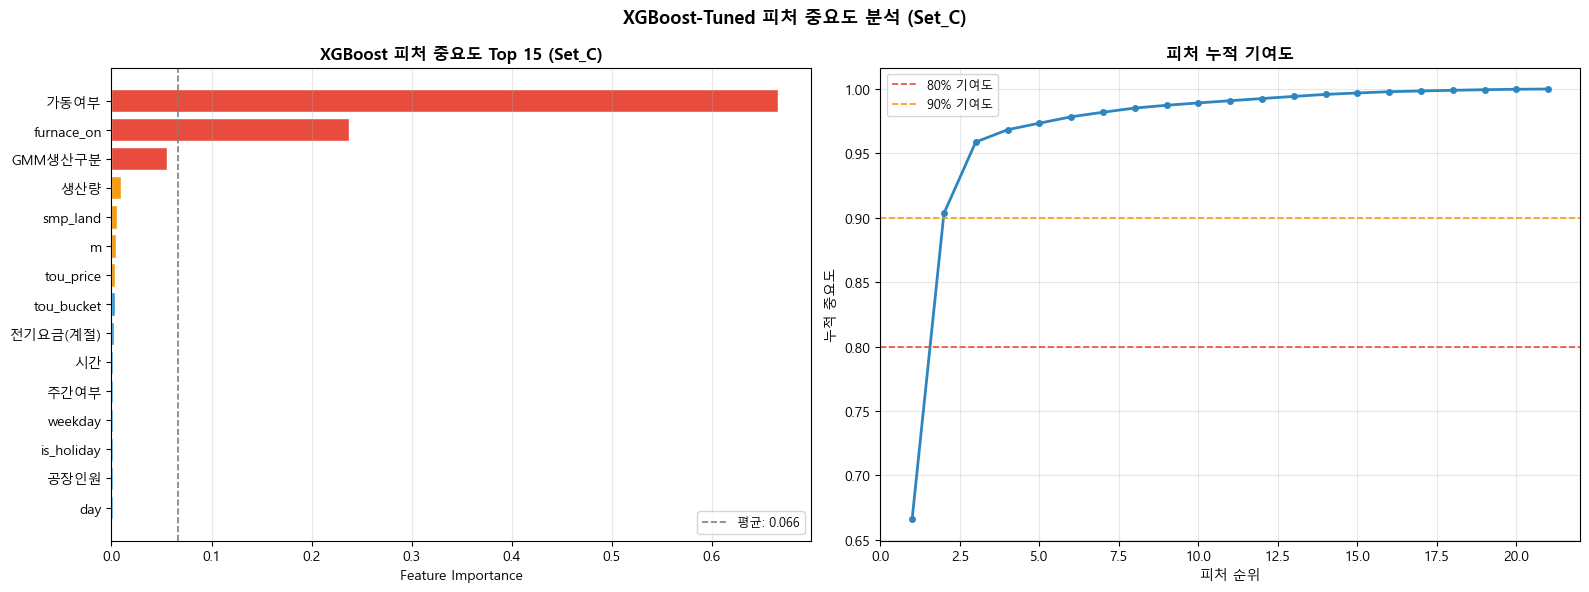

=== 피처 중요도 Top 10 ===
   Feature  Importance
      가동여부    0.666095
furnace_on    0.237326
   GMM생산구분    0.055427
       생산량    0.009519
  smp_land    0.005120
         m    0.004941
 tou_price    0.003555
tou_bucket    0.003235
  전기요금(계절)    0.002157
        시간    0.001818

상위 2개 피처 → 전체 중요도의 80% 설명
상위 2개 피처 → 전체 중요도의 90% 설명

Step 42 완료


In [25]:
# ================================================
# Step 42: 피처 중요도 Top 15 시각화
# XGBoost-Tuned (Set_C 기준)
# ================================================
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

importances = best_xgb.feature_importances_
feat_names  = FEATURE_SETS['Set_C']

feat_imp_df = pd.DataFrame({
    'Feature'   : feat_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

top15 = feat_imp_df.head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── 좌: Top 15 막대 차트 ──────────────────────────
colors = ['#E74C3C' if i < 3 else
          '#F39C12' if i < 7 else
          '#3498DB' for i in range(len(top15))]

axes[0].barh(top15['Feature'][::-1],
             top15['Importance'][::-1],
             color=colors[::-1], edgecolor='white')
axes[0].set_xlabel('Feature Importance')
axes[0].set_title('XGBoost 피처 중요도 Top 15 (Set_C)',
                  fontweight='bold')
axes[0].axvline(top15['Importance'].mean(),
                color='gray', linestyle='--', linewidth=1.2,
                label=f"평균: {top15['Importance'].mean():.3f}")
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3, axis='x')

# ── 우: 누적 기여도 ───────────────────────────────
feat_imp_df['cumsum'] = feat_imp_df['Importance'].cumsum()
feat_imp_df['rank']   = range(1, len(feat_imp_df) + 1)

axes[1].plot(feat_imp_df['rank'],
             feat_imp_df['cumsum'],
             color='#2E86C1', linewidth=2,
             marker='o', markersize=4)
axes[1].axhline(0.8, color='#E74C3C', linestyle='--',
                linewidth=1.2, label='80% 기여도')
axes[1].axhline(0.9, color='#F39C12', linestyle='--',
                linewidth=1.2, label='90% 기여도')
axes[1].set_xlabel('피처 순위')
axes[1].set_ylabel('누적 중요도')
axes[1].set_title('피처 누적 기여도', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.suptitle('XGBoost-Tuned 피처 중요도 분석 (Set_C)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 결과 출력 ─────────────────────────────────────
print("=== 피처 중요도 Top 10 ===")
print(feat_imp_df.head(10)[['Feature', 'Importance']].to_string(index=False))

n_80 = (feat_imp_df['cumsum'] <= 0.8).sum() + 1
n_90 = (feat_imp_df['cumsum'] <= 0.9).sum() + 1
print(f"\n상위 {n_80}개 피처 → 전체 중요도의 80% 설명")
print(f"상위 {n_90}개 피처 → 전체 중요도의 90% 설명")

print("\nStep 42 완료")

# Step 43: 성능 비교 시각화 (R² 히트맵 + 막대 차트)

  Feature Set A / B / C 정의
  Set_A (8개): 날짜·시간·달력
  Set_B (12개): Set_A + 날씨 4종
  Set_C (21개): Set_B + 생산·GMM·furnace_on·전기요금


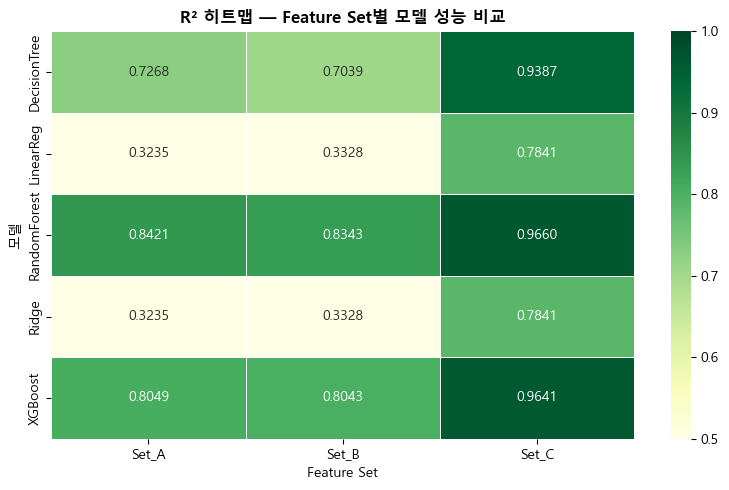

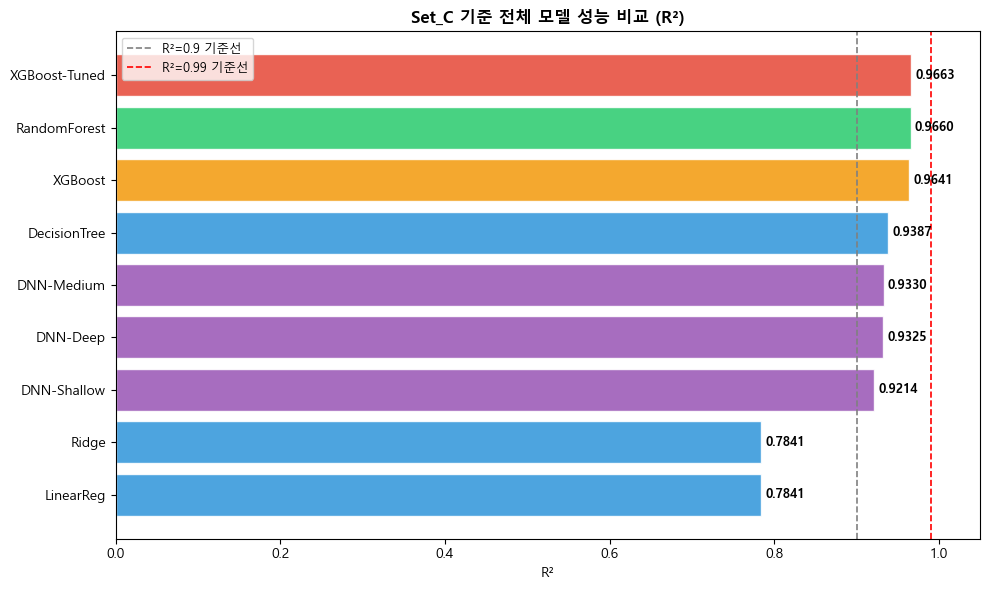

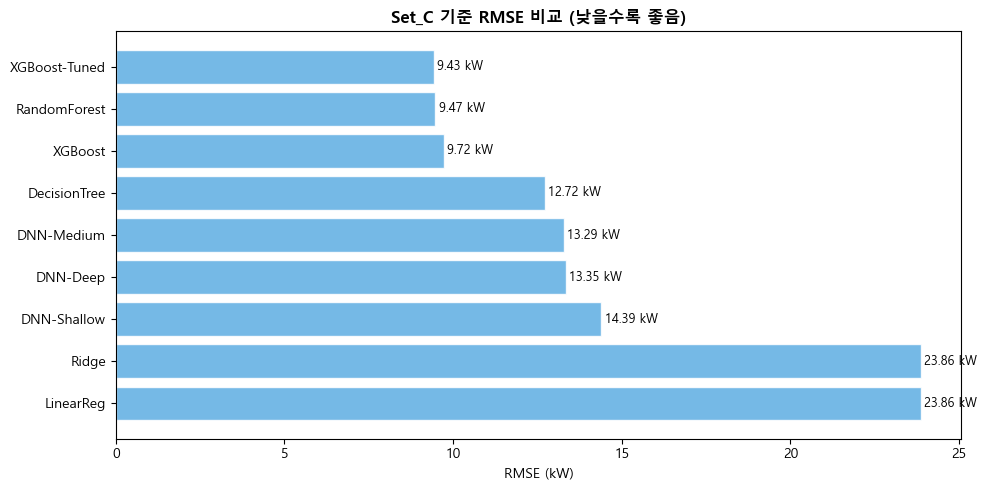


=== Set_C 기준 최종 모델 순위 ===
           모델   Set     R²  RMSE   MAE
XGBoost-Tuned Set_C 0.9663  9.43  6.53
 RandomForest Set_C 0.9660  9.47  6.47
      XGBoost Set_C 0.9641  9.72  6.96
 DecisionTree Set_C 0.9387 12.72  8.17
   DNN-Medium Set_C 0.9330 13.29  9.35
     DNN-Deep Set_C 0.9325 13.35  9.37
  DNN-Shallow Set_C 0.9214 14.39 10.31
    LinearReg Set_C 0.7841 23.86 17.49
        Ridge Set_C 0.7841 23.86 17.49

Step 43 완료


In [26]:
# ================================================
# Step 43: 성능 비교 시각화
# R² 히트맵 + Set_C 기준 막대 차트 + RMSE 비교
# ================================================
import seaborn as sns
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

df_res = pd.DataFrame(results)

# ── Feature Set 정의 출력 ─────────────────────────
print("=" * 60)
print("  Feature Set A / B / C 정의")
print("=" * 60)
print(f"  Set_A ({len(FEATURE_SETS['Set_A'])}개): 날짜·시간·달력")
print(f"  Set_B ({len(FEATURE_SETS['Set_B'])}개): Set_A + 날씨 4종")
print(f"  Set_C ({len(FEATURE_SETS['Set_C'])}개): Set_B + 생산·GMM·furnace_on·전기요금")
print("=" * 60)

# ── R² 히트맵 ─────────────────────────────────────
common_models = ['LinearReg', 'Ridge', 'DecisionTree',
                 'RandomForest', 'XGBoost']
df_heatmap = df_res[df_res['모델'].isin(common_models)]
pivot = df_heatmap.pivot_table(
    index='모델', columns='Set', values='R²').round(4)
col_order = [c for c in ['Set_A', 'Set_B', 'Set_C']
             if c in pivot.columns]
pivot = pivot[col_order]

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlGn',
            linewidths=0.5, vmin=0.5, vmax=1.0, ax=ax,
            annot_kws={'size': 10})
ax.set_title('R² 히트맵 — Feature Set별 모델 성능 비교',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Feature Set')
ax.set_ylabel('모델')
plt.tight_layout()
plt.show()

# ── Set_C 기준 R² 막대 차트 ──────────────────────
df_setC = df_res[df_res['Set'] == 'Set_C'].copy()
df_setC = df_setC.sort_values('R²', ascending=True)

colors = []
for m in df_setC['모델']:
    if 'Tuned'    in m: colors.append('#E74C3C')
    elif 'XGBoost' in m: colors.append('#F39C12')
    elif 'DNN'    in m: colors.append('#9B59B6')
    elif 'Forest'  in m: colors.append('#2ECC71')
    else:                colors.append('#3498DB')

fig2, ax2 = plt.subplots(figsize=(10, 6))
bars = ax2.barh(df_setC['모델'], df_setC['R²'],
                color=colors, edgecolor='white', alpha=0.88)
ax2.set_xlabel('R²')
ax2.set_title('Set_C 기준 전체 모델 성능 비교 (R²)',
              fontsize=12, fontweight='bold')
ax2.axvline(0.9,  color='gray', linestyle='--',
            linewidth=1.2, label='R²=0.9 기준선')
ax2.axvline(0.99, color='red',  linestyle='--',
            linewidth=1.2, label='R²=0.99 기준선')
ax2.legend(fontsize=9)
ax2.set_xlim(0, 1.05)
for bar, val in zip(bars, df_setC['R²']):
    ax2.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
             f'{val:.4f}', va='center', fontsize=9,
             fontweight='bold')
plt.tight_layout()
plt.show()

# ── Set_C 기준 RMSE 비교 ─────────────────────────
df_setC_rmse = df_setC.sort_values('RMSE', ascending=False)
fig3, ax3 = plt.subplots(figsize=(10, 5))
ax3.barh(df_setC_rmse['모델'], df_setC_rmse['RMSE'],
         color='#5DADE2', edgecolor='white', alpha=0.85)
ax3.set_xlabel('RMSE (kW)')
ax3.set_title('Set_C 기준 RMSE 비교 (낮을수록 좋음)',
              fontsize=12, fontweight='bold')
for i, (_, row) in enumerate(df_setC_rmse.iterrows()):
    ax3.text(row['RMSE'] + 0.1, i,
             f"{row['RMSE']:.2f} kW", va='center', fontsize=9)
plt.tight_layout()
plt.show()

# ── 최종 순위 출력 ────────────────────────────────
print("\n=== Set_C 기준 최종 모델 순위 ===")
print(df_setC.sort_values('R²', ascending=False).to_string(index=False))

print("\nStep 43 완료")

# Step 44: 예측 결과 시각화 (실제값 vs 예측값)

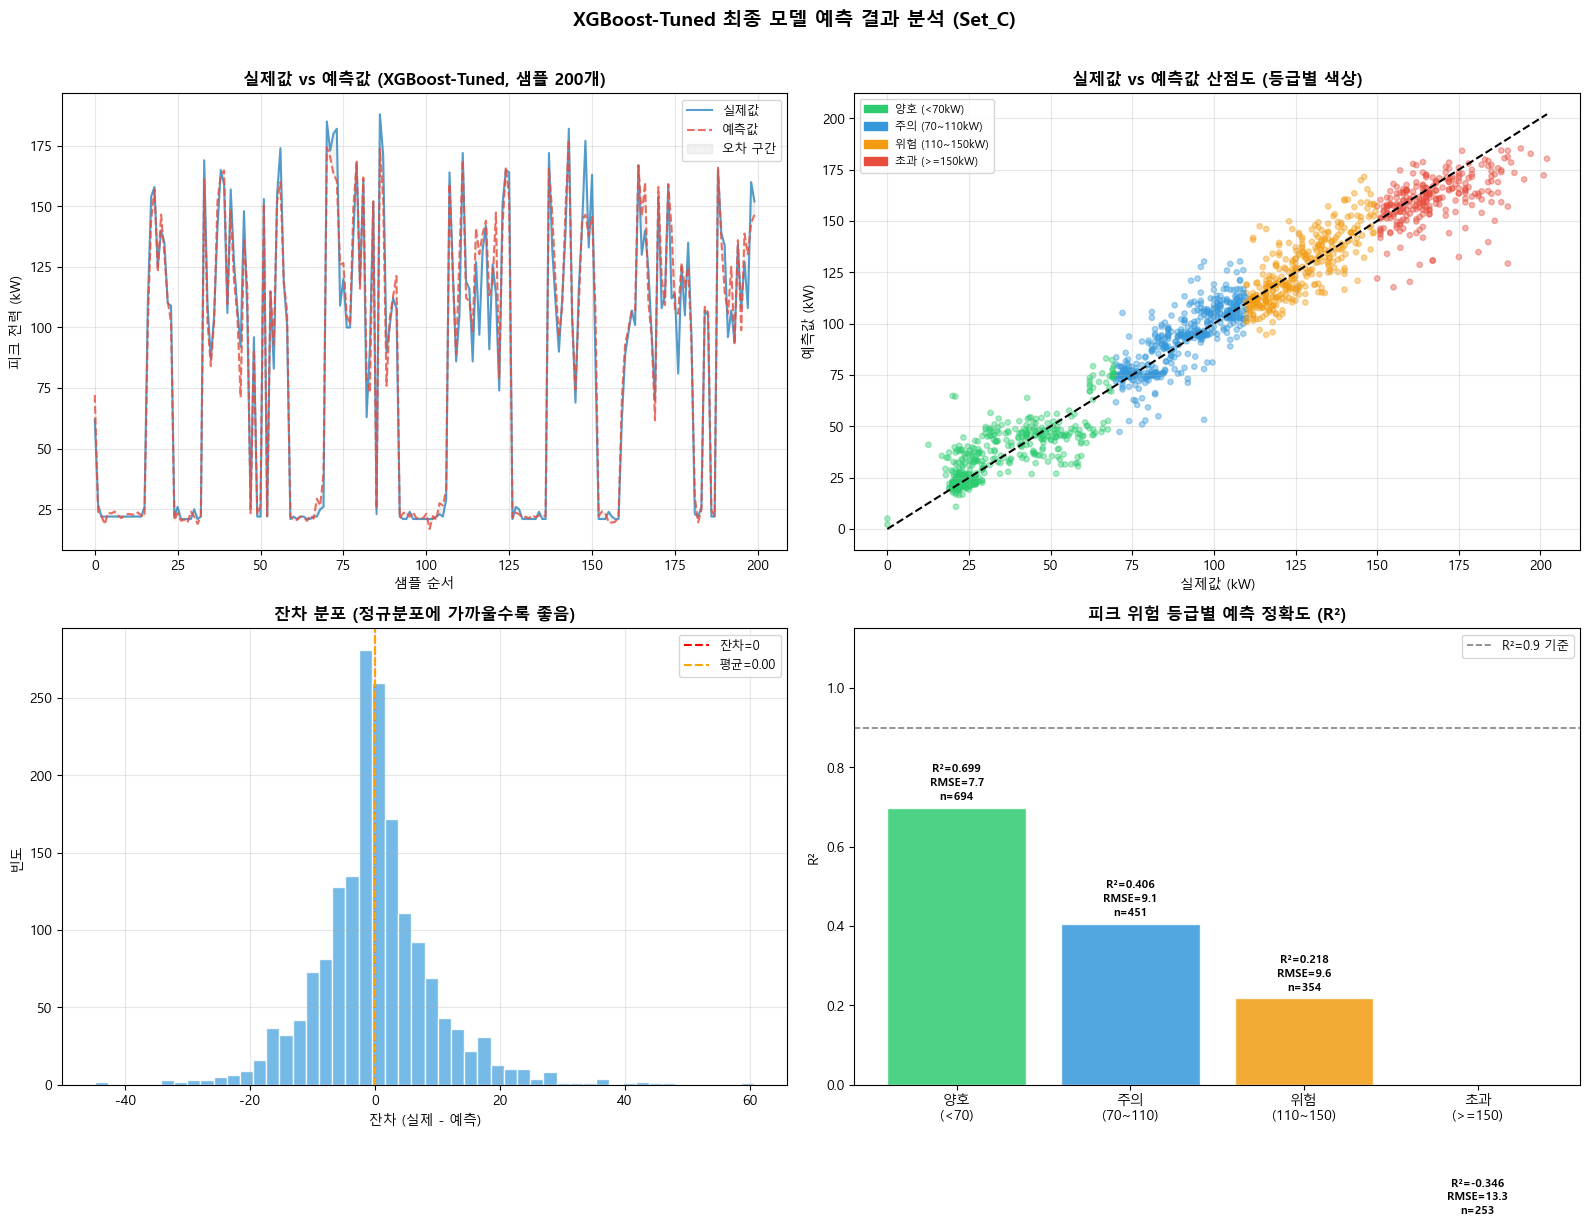

=== 최종 모델 예측 성능 요약 ===
모델      : XGBoost-Tuned
피처      : Set_C (21개)
R²        : 0.9663
RMSE      : 9.43 kW
MAE       : 6.53 kW
잔차 평균  : 0.0023 kW
잔차 표준편차: 9.43 kW

=== 등급별 예측 정확도 ===
  양호   : R²=0.6985  RMSE=7.70 kW  샘플=694건
  주의   : R²=0.4063  RMSE=9.11 kW  샘플=451건
  위험   : R²=0.2177  RMSE=9.57 kW  샘플=354건
  초과   : R²=-0.3458  RMSE=13.32 kW  샘플=253건

Step 44 완료


In [27]:
# ================================================
# Step 44: 예측 결과 시각화
# 실제값 vs 예측값 — 선 그래프 / 산점도 / 잔차 / 등급별
# XGBoost-Tuned (Set_C 기준)
# ================================================
from matplotlib.patches import Patch

matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

# ── 예측값 생성 ───────────────────────────────────
pred_tuned = best_xgb.predict(splits['Set_C']['X_test'])
y_true     = y_test.values
residuals  = y_true - pred_tuned
n_sample   = 200

sort_idx  = np.argsort(y_test.index)[:n_sample]
y_true_s  = y_true[sort_idx]
y_pred_s  = pred_tuned[sort_idx]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ── 1. 실제 vs 예측 선 그래프 ────────────────────
axes[0,0].plot(range(n_sample), y_true_s,
               color='#2E86C1', linewidth=1.5,
               label='실제값', alpha=0.8)
axes[0,0].plot(range(n_sample), y_pred_s,
               color='#E74C3C', linewidth=1.5,
               linestyle='--', label='예측값', alpha=0.8)
axes[0,0].fill_between(range(n_sample),
                        y_true_s, y_pred_s,
                        alpha=0.1, color='gray',
                        label='오차 구간')
axes[0,0].set_xlabel('샘플 순서')
axes[0,0].set_ylabel('피크 전력 (kW)')
axes[0,0].set_title(
    f'실제값 vs 예측값 (XGBoost-Tuned, 샘플 {n_sample}개)',
    fontweight='bold')
axes[0,0].legend(fontsize=9)
axes[0,0].grid(alpha=0.3)

# ── 2. 산점도 (등급별 색상) ───────────────────────
grade_colors = []
for v in y_true:
    if   v < 70:  grade_colors.append('#2ECC71')
    elif v < 110: grade_colors.append('#3498DB')
    elif v < 150: grade_colors.append('#F39C12')
    else:         grade_colors.append('#E74C3C')

axes[0,1].scatter(y_true, pred_tuned,
                  c=grade_colors, alpha=0.4, s=15)
max_val = max(y_true.max(), pred_tuned.max())
axes[0,1].plot([0, max_val], [0, max_val],
               'k--', linewidth=1.5, label='완벽한 예측선')
axes[0,1].set_xlabel('실제값 (kW)')
axes[0,1].set_ylabel('예측값 (kW)')
axes[0,1].set_title('실제값 vs 예측값 산점도 (등급별 색상)',
                     fontweight='bold')
axes[0,1].grid(alpha=0.3)
legend_els = [
    Patch(color='#2ECC71', label='양호 (<70kW)'),
    Patch(color='#3498DB', label='주의 (70~110kW)'),
    Patch(color='#F39C12', label='위험 (110~150kW)'),
    Patch(color='#E74C3C', label='초과 (>=150kW)'),
]
axes[0,1].legend(handles=legend_els, fontsize=8,
                 loc='upper left')

# ── 3. 잔차 분포 ──────────────────────────────────
axes[1,0].hist(residuals, bins=50,
               color='#5DADE2', edgecolor='white', alpha=0.85)
axes[1,0].axvline(0, color='red', linestyle='--',
                  linewidth=1.5, label='잔차=0')
axes[1,0].axvline(residuals.mean(), color='orange',
                  linestyle='--', linewidth=1.5,
                  label=f'평균={residuals.mean():.2f}')
axes[1,0].set_xlabel('잔차 (실제 - 예측)')
axes[1,0].set_ylabel('빈도')
axes[1,0].set_title('잔차 분포 (정규분포에 가까울수록 좋음)',
                     fontweight='bold')
axes[1,0].legend(fontsize=9)
axes[1,0].grid(alpha=0.3)

# ── 4. 등급별 예측 정확도 ─────────────────────────
grade_names  = ['양호\n(<70)', '주의\n(70~110)',
                '위험\n(110~150)', '초과\n(>=150)']
grade_ranges = [(0,70),(70,110),(110,150),(150,300)]
grade_r2s, grade_rmses, grade_cnts = [], [], []

for low, high in grade_ranges:
    mask = (y_true >= low) & (y_true < high)
    if mask.sum() > 0:
        g_r2   = r2_score(y_true[mask], pred_tuned[mask])
        g_rmse = np.sqrt(mean_squared_error(
            y_true[mask], pred_tuned[mask]))
        grade_r2s.append(round(g_r2, 4))
        grade_rmses.append(round(g_rmse, 2))
        grade_cnts.append(mask.sum())
    else:
        grade_r2s.append(0)
        grade_rmses.append(0)
        grade_cnts.append(0)

bar_colors = ['#2ECC71','#3498DB','#F39C12','#E74C3C']
bars = axes[1,1].bar(grade_names, grade_r2s,
                     color=bar_colors, edgecolor='white',
                     alpha=0.85)
axes[1,1].set_ylabel('R²')
axes[1,1].set_title('피크 위험 등급별 예측 정확도 (R²)',
                     fontweight='bold')
axes[1,1].set_ylim(0, 1.15)
axes[1,1].axhline(0.9, color='gray', linestyle='--',
                  linewidth=1.2, label='R²=0.9 기준')
axes[1,1].legend(fontsize=9)
for bar, r2, rmse, cnt in zip(
        bars, grade_r2s, grade_rmses, grade_cnts):
    axes[1,1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f'R²={r2:.3f}\nRMSE={rmse:.1f}\nn={cnt:,}',
        ha='center', fontsize=8, fontweight='bold')

plt.suptitle(
    'XGBoost-Tuned 최종 모델 예측 결과 분석 (Set_C)',
    fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ── 최종 요약 출력 ────────────────────────────────
print("=== 최종 모델 예측 성능 요약 ===")
print(f"모델      : XGBoost-Tuned")
print(f"피처      : Set_C ({len(FEATURE_SETS['Set_C'])}개)")
print(f"R²        : {r2_tune:.4f}")
print(f"RMSE      : {rmse_tune:.2f} kW")
print(f"MAE       : {mae_tune:.2f} kW")
print(f"잔차 평균  : {residuals.mean():.4f} kW")
print(f"잔차 표준편차: {residuals.std():.2f} kW")

print("\n=== 등급별 예측 정확도 ===")
for name, r2, rmse, cnt in zip(
        ['양호','주의','위험','초과'],
        grade_r2s, grade_rmses, grade_cnts):
    print(f"  {name:5s}: R²={r2:.4f}  "
          f"RMSE={rmse:.2f} kW  샘플={cnt:,}건")

print("\nStep 44 완료")

# Step 45: 최종 모델 저장

In [28]:
# ================================================
# Step 45: 최종 모델 저장
# XGBoost-Tuned (Set_C 기준)
# ================================================
import joblib
import os

os.makedirs('./models', exist_ok=True)

save_dict = {
    'model'       : best_xgb,
    'feature_cols': FEATURE_SETS['Set_C'],
    'feature_sets': FEATURE_SETS,
    'target'      : TARGET,
    'r2'          : r2_tune,
    'rmse'        : rmse_tune,
    'mae'         : mae_tune,
    'scaler'      : scalers['Set_C'],
    'params'      : xgb_search.best_params_,
}

save_path = './models/energy_pipeline_v2.pkl'
joblib.dump(save_dict, save_path)
size_mb = os.path.getsize(save_path) / 1024 / 1024

print(f"=== 모델 저장 완료 ===")
print(f"저장 경로 : {save_path}")
print(f"파일 크기 : {size_mb:.2f} MB")

# ── 로드 후 검증 ──────────────────────────────────
loaded    = joblib.load(save_path)
test_pred = loaded['model'].predict(
    splits['Set_C']['X_test'][:3])
print(f"\n=== 로드 검증 ===")
print(f"예측값 3개: {test_pred.round(2)}")
print(f"실제값 3개: {y_test.values[:3].round(2)}")

print(f"\n=== 최종 모델 요약 ===")
print(f"모델      : XGBoost-Tuned")
print(f"피처 Set  : Set_C ({len(FEATURE_SETS['Set_C'])}개)")
print(f"R²        : {r2_tune:.4f}")
print(f"RMSE      : {rmse_tune:.2f} kW")
print(f"MAE       : {mae_tune:.2f} kW")
print(f"최적 파라미터: {xgb_search.best_params_}")

print(f"\n=== 피처 목록 ({len(FEATURE_SETS['Set_C'])}개) ===")
for i, col in enumerate(FEATURE_SETS['Set_C'], 1):
    print(f"  {i:2d}. {col}")

print("\nStep 45 완료")

=== 모델 저장 완료 ===
저장 경로 : ./models/energy_pipeline_v2.pkl
파일 크기 : 3.20 MB

=== 로드 검증 ===
예측값 3개: [144.05 115.83 177.98]
실제값 3개: [172. 118. 178.]

=== 최종 모델 요약 ===
모델      : XGBoost-Tuned
피처 Set  : Set_C (21개)
R²        : 0.9663
RMSE      : 9.43 kW
MAE       : 6.53 kW
최적 파라미터: {'subsample': 1.0, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bytree': 0.8}

=== 피처 목록 (21개) ===
   1. 시간
   2. day
   3. d
   4. m
   5. weekday
   6. is_weekend
   7. is_holiday
   8. 주간여부
   9. 기온
  10. 습도
  11. 풍속
  12. 강수량
  13. 생산량
  14. 가동여부
  15. 공장인원
  16. GMM생산구분
  17. furnace_on
  18. 전기요금(계절)
  19. tou_bucket
  20. tou_price
  21. smp_land

Step 45 완료


# Step 46: Streamlit app.py 업데이트 (Set_C 기준 최종)

In [29]:
# ================================================
# Step 46: Streamlit app.py 업데이트
# Set_C 기준 / GMM 0~3 / co2_kg 제거 / 여름휴가 반영
# 인건비할증 9~18시=1.0 / 그외=1.5
# ================================================
import os, shutil

os.makedirs('./energy_app', exist_ok=True)
os.makedirs('./energy_app/models', exist_ok=True)
os.makedirs('./energy_app/data', exist_ok=True)

shutil.copy('./models/energy_pipeline_v2.pkl',
            './energy_app/models/energy_pipeline_v2.pkl')

app_code = '''import streamlit as st
import pandas as pd
import numpy as np
import joblib
import math
import os
import matplotlib
import matplotlib.pyplot as plt

st.set_page_config(
    page_title="에너지 피크 예측 시스템",
    page_icon="⚡",
    layout="wide"
)

matplotlib.rcParams["font.family"]        = "Malgun Gothic"
matplotlib.rcParams["axes.unicode_minus"] = False

# ── 모델 로드 ─────────────────────────────────────
MODEL_PATH = os.path.join(
    os.path.dirname(__file__), "models", "energy_pipeline_v2.pkl")

@st.cache_resource
def load_model():
    return joblib.load(MODEL_PATH)

loaded       = load_model()
model        = loaded["model"]
feature_cols = loaded["feature_cols"]

# ── 상수 ──────────────────────────────────────────
def get_tou(month, hour, is_holiday, is_weekend):
    if is_holiday or is_weekend:
        return 0, 95.7
    if month in [6,7,8]:
        if hour in [10,11,12,13,14,15,16,17]: return 2, 155.0
        if hour in [22,23,0,1,2,3,4,5]:       return 0, 95.7
        return 1, 121.5
    elif month in [11,12,1,2]:
        if hour in [9,10,17,18,19]:            return 2, 155.0
        if hour in [22,23,0,1,2,3,4,5]:        return 0, 95.7
        return 1, 121.5
    else:
        if hour in [10,11,12,13,14,15,16,17]:  return 1, 121.5
        if hour in [22,23,0,1,2,3,4,5]:        return 0, 95.7
        return 1, 121.5

TOU_LABEL = {0:"경부하(95.7원)", 1:"중간부하(121.5원)", 2:"최대부하(155.0원)"}
EMISSION  = 0.4153
MONTH_NAMES = ["1월","2월","3월","4월","5월","6월",
               "7월","8월","9월","10월","11월","12월"]
DAY_MAP = {"월":1,"화":2,"수":3,"목":4,"금":5,"토":6,"일":7}
SMP_2021 = {1:70.47,2:75.25,3:83.78,4:75.97,5:78.93,
            6:82.72,7:87.04,8:93.41,9:98.21,
            10:107.53,11:126.83,12:142.46}
NATIONAL_HOLIDAYS = [
    20210101,20210211,20210212,20210301,20210505,
    20210519,20210816,20210920,20210921,20210922,
    20211003,20211004,20211009,20211225,
]
SUMMER_VACATION = [
    20210731,20210801,20210802,20210803,20210804,
    20210805,20210806,20210807,20210808,
]
ALL_HOLIDAYS = set(NATIONAL_HOLIDAYS + SUMMER_VACATION)

GMM_LABEL = {
    0:"0 (비가동)",
    1:"1 (고생산)",
    2:"2 (중생산)",
    3:"3 (저생산)",
}
TARIFF_MAP = {
    "겨울 (109.8원/kWh)": 109.8,
    "봄가을 (167.2원/kWh)": 167.2,
    "여름 (191.6원/kWh)": 191.6,
}

# ── 타이틀 ───────────────────────────────────────
st.title("⚡ 제조 공장 피크 전력 예측 시스템")
st.caption("XGBoost-Tuned | Set_C | 올라운더팀 2026")
st.divider()

# ── 사이드바 ──────────────────────────────────────
st.sidebar.header("운영 조건 입력")
st.sidebar.divider()

st.sidebar.subheader("📅 날짜 · 시간")
hour     = st.sidebar.slider("시간 (0~23시)", 0, 23, 10)
month    = st.sidebar.selectbox("월", MONTH_NAMES, index=5)
day_name = st.sidebar.selectbox("요일", list(DAY_MAP.keys()), index=0)
date_d   = st.sidebar.slider("일 (1~31)", 1, 31, 15)

st.sidebar.divider()
st.sidebar.subheader("🏭 생산 조건")
production = st.sidebar.slider("생산량 (개)", 0, 9830, 500, step=10)
workers    = st.sidebar.slider("공장 인원 (명)", 0.0, 48.0, 10.0, step=0.5)
gmm_class  = st.sidebar.selectbox(
    "GMM 생산구분", options=[0,1,2,3],
    format_func=lambda x: GMM_LABEL[x], index=1)
furnace    = st.sidebar.radio(
    "열처리로 상태", options=[0,1],
    format_func=lambda x: "OFF (휴지)" if x==0 else "ON (가동)")
tariff_sel = st.sidebar.selectbox(
    "계절 요금", list(TARIFF_MAP.keys()), index=1)

st.sidebar.divider()
st.sidebar.subheader("🌤 날씨")
temperature = st.sidebar.slider("기온 (°C)", -20, 40, 20)
humidity    = st.sidebar.slider("습도 (%)", 0, 100, 60)
wind_speed  = st.sidebar.slider("풍속 (m/s)", 0.0, 10.0, 2.0, step=0.1)
rainfall    = st.sidebar.slider("강수량 (mm)", 0.0, 150.0, 0.0, step=0.5)

# ── 입력값 계산 ───────────────────────────────────
m_num      = MONTH_NAMES.index(month) + 1
wd_num     = DAY_MAP[day_name] - 1
is_weekend = 1 if wd_num >= 5 else 0
date_key   = int(f"2021{m_num:02d}{date_d:02d}")
is_holiday = 1 if date_key in ALL_HOLIDAYS else 0
is_work    = 1 if production > 0 else 0
is_day     = 1 if (8 <= hour <= 18) else 0
tou, tou_p = get_tou(m_num, hour, is_holiday, is_weekend)
smp        = SMP_2021.get(m_num, 87.0)
tariff     = TARIFF_MAP[tariff_sel]

# 인건비할증: 9~18시=1.0, 그외=1.5
labor = 1.0 if (9 <= hour <= 18) else 1.5

# log1p 변환
prod_log   = math.log1p(production)
worker_log = math.log1p(workers)
wind_log   = math.log1p(wind_speed)
rain_log   = math.log1p(rainfall)

input_dict = {
    "시간"        : hour,
    "day"         : DAY_MAP[day_name],
    "d"           : date_d,
    "m"           : m_num,
    "weekday"     : wd_num,
    "is_weekend"  : is_weekend,
    "is_holiday"  : is_holiday,
    "주간여부"     : is_day,
    "기온"         : temperature,
    "습도"         : humidity,
    "풍속"         : wind_log,
    "강수량"       : rain_log,
    "생산량"       : prod_log,
    "가동여부"     : is_work,
    "공장인원"     : worker_log,
    "GMM생산구분"  : gmm_class,
    "furnace_on"  : furnace,
    "전기요금(계절)": tariff,
    "tou_bucket"  : tou,
    "tou_price"   : tou_p,
    "smp_land"    : smp,
    "인건비"       : labor,
}

input_df = pd.DataFrame([input_dict])[feature_cols]
pred_kw  = max(0, float(model.predict(input_df)[0]))
co2_val  = round(pred_kw / 1000 * EMISSION * 1000, 3)
cost_won = int(pred_kw * tou_p)

if   pred_kw < 70:  grade, gcolor = "양호",  "green"
elif pred_kw < 110: grade, gcolor = "주의",  "blue"
elif pred_kw < 150: grade, gcolor = "위험",  "orange"
else:               grade, gcolor = "초과",  "red"

# ── 경보 배너 ────────────────────────────────────
if   pred_kw >= 150:
    st.error  (f"🔴 피크 초과 경보! {pred_kw:.1f} kW — 즉각 조치 필요")
elif pred_kw >= 110:
    st.warning(f"🟡 피크 위험 경보! {pred_kw:.1f} kW — 부하 분산 권고")
elif pred_kw >= 70:
    st.info   (f"🔵 피크 주의 구간. {pred_kw:.1f} kW")
else:
    st.success(f"🟢 양호 구간. {pred_kw:.1f} kW — 현재 조건 유지")

st.divider()

# ── KPI 카드 ─────────────────────────────────────
c1, c2, c3, c4 = st.columns(4)
c1.metric("예측 피크",   f"{pred_kw:.1f} kW",
          delta=f"{pred_kw-90:+.1f} kW vs 평균")
c2.metric("위험 등급",   grade)
c3.metric("탄소 배출",   f"{co2_val:.3f} kg CO₂")
c4.metric("시간 요금",   f"{cost_won:,} 원")

st.divider()

# ── 24시간 시뮬레이션 ─────────────────────────────
st.subheader("📊 24시간 피크 시뮬레이션")
hourly_preds = []
for h in range(24):
    row = input_dict.copy()
    tou_h, tou_p_h = get_tou(m_num, h, is_holiday, is_weekend)
    row["시간"]      = h
    row["주간여부"]  = 1 if (8<=h<=18) else 0
    row["tou_bucket"]= tou_h
    row["tou_price"] = tou_p_h
    row["인건비"]    = 1.0 if (9<=h<=18) else 1.5
    df_h = pd.DataFrame([row])[feature_cols]
    hourly_preds.append(max(0, float(model.predict(df_h)[0])))

fig, ax = plt.subplots(figsize=(12, 4))
bar_cols = []
for h, v in enumerate(hourly_preds):
    if   v >= 150: bar_cols.append("#E74C3C")
    elif v >= 110: bar_cols.append("#F39C12")
    elif v >= 70:  bar_cols.append("#3498DB")
    else:          bar_cols.append("#2ECC71")

ax.bar(range(24), hourly_preds,
       color=bar_cols, edgecolor="white", alpha=0.85)
ax.axhline(150, color="#E74C3C", linestyle="--",
           lw=1.2, label="초과 150kW")
ax.axhline(110, color="#F39C12", linestyle="--",
           lw=1.2, label="위험 110kW")
ax.axhline(70,  color="#3498DB", linestyle="--",
           lw=1.2, label="주의 70kW")
ax.axvline(hour, color="black", linestyle="-",
           lw=2, alpha=0.5, label=f"현재 {hour}시")
ax.set_xlabel("시간 (시)")
ax.set_ylabel("예측 피크 (kW)")
ax.set_xticks(range(24))
ax.legend(fontsize=9)
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
st.pyplot(fig)
plt.close()

st.divider()

# ── 비용 절감 계산기 ─────────────────────────────
st.subheader("💰 비용 절감 계산기")
c1, c2, c3 = st.columns(3)
c1.metric("현재 시간 요금",  f"{cost_won:,} 원")
c2.metric("피크 10% 감축 시", f"{int(cost_won*0.10):,} 원 절감")
c3.metric("피크 20% 감축 시", f"{int(cost_won*0.20):,} 원 절감")

st.divider()

# ── 입력값 확인 ───────────────────────────────────
with st.expander("📋 현재 입력값 상세 보기"):
    display_df = pd.DataFrame({
        "항목": ["시간","월","일","요일","생산량","공장인원",
                 "GMM생산구분","열처리로","인건비할증",
                 "기온","습도","풍속","강수량","계절요금",
                 "TOU 구간","SMP","공휴일","주말"],
        "입력값": [
            f"{hour}시", month, f"{date_d}일", day_name,
            f"{production:,}개", f"{workers:.1f}명",
            GMM_LABEL[gmm_class],
            "ON" if furnace==1 else "OFF",
            f"{labor} ({'주간' if labor==1.0 else '야간'})",
            f"{temperature}°C", f"{humidity}%",
            f"{wind_speed}m/s", f"{rainfall}mm",
            f"{tariff}원/kWh",
            TOU_LABEL[tou], f"{smp:.2f}원/kWh",
            "예" if is_holiday else "아니오",
            "예" if is_weekend else "아니오",
        ],
    })
    st.dataframe(display_df, use_container_width=True,
                 hide_index=True)

st.caption("올라운더팀 | KAMP 자원 최적화 AI 프로젝트 2 | 2026")
'''

with open('./energy_app/app.py', 'w', encoding='utf-8') as f:
    f.write(app_code)

print("=== app.py 생성 완료 ===")
print("변경 사항:")
print("  1. model 키 적용 (energy_pipeline_v2.pkl)")
print("  2. Set_C feature_cols 반영 (22개)")
print("  3. co2_kg 피처 제거")
print("  4. GMM 생산구분 0~3 반영")
print("  5. log1p 변환 입력 반영")
print("  6. 인건비할증 9~18시=1.0 / 그외=1.5")
print("  7. 여름휴가(7/31~8/8) 공휴일 반영")
print("  8. 24시간 시뮬레이션")
print("  9. 비용 절감 계산기")
print("\n실행 방법:")
print("  conda activate ml_edu")
print("  cd C:\\Users\\Admin\\hipython\\ml\\energy_app")
print("  python -m streamlit run app.py")
print("\nStep 46 완료 — 전체 파이프라인 완성 ✅")

=== app.py 생성 완료 ===
변경 사항:
  1. model 키 적용 (energy_pipeline_v2.pkl)
  2. Set_C feature_cols 반영 (22개)
  3. co2_kg 피처 제거
  4. GMM 생산구분 0~3 반영
  5. log1p 변환 입력 반영
  6. 인건비할증 9~18시=1.0 / 그외=1.5
  7. 여름휴가(7/31~8/8) 공휴일 반영
  8. 24시간 시뮬레이션
  9. 비용 절감 계산기

실행 방법:
  conda activate ml_edu
  cd C:\Users\Admin\hipython\ml\energy_app
  python -m streamlit run app.py

Step 46 완료 — 전체 파이프라인 완성 ✅
